In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
sns.set(rc={'figure.dpi':300})

In [2]:
import sklearn

# Linear regression

<img src="img/linear_regression.png" alt="linear_regression" width="800" style="float: left;"/>

Используя функцию [pd.read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) прочтите данные из файла "data/advertising.csv".

In [3]:
data = pd.read_csv("data/advertising.csv")
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


Полученная таблица содержит данные о затратах фирмы на рекламу в различных медиа и выручке, полученной фирмой. Задача - найти зависимость выручки от затрат по каждой категории.

In [4]:
target = 'Sales'
features = [c for c in data.columns if c != target]

Прежде чем обучать модель машинного обучения, следует провести визуализацию данных, чтобы попробовать оценить возможные зависимости "на глаз". Привиденные ниже диаграммы рассеяния, к примеру, демонстрируют сильную линейную зависимость целеволго свойства от одного из признаков.

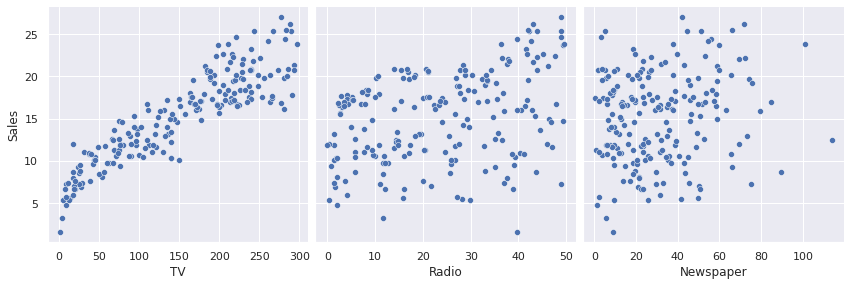

In [5]:
sns.pairplot(data, x_vars=features, y_vars=target, height=4, kind='scatter')
plt.show()

Еще один способ визуализации данных. Графики ниже позволяют оценить не только зависимости целевого свойства (обозначено цветом на графиках) от дескрипторов, но и зависимости между дескрипторами. В нашем случае графики показывают что все дескрипторы между собой независимы.

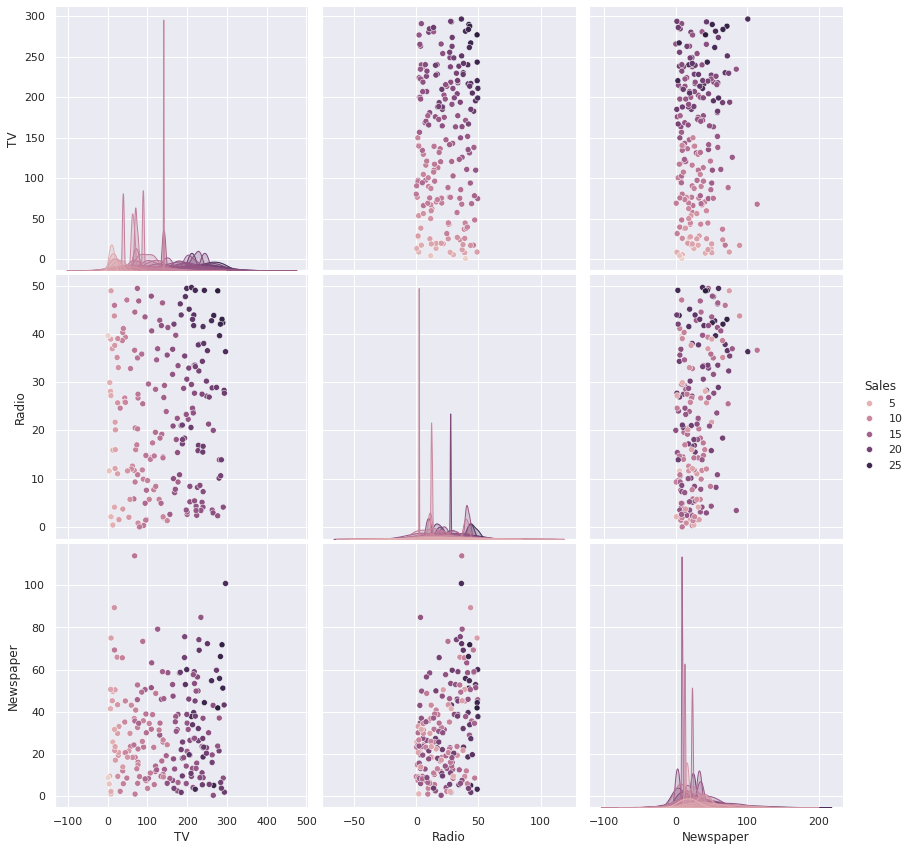

In [6]:
sns.pairplot(data, x_vars=features, y_vars=features, height=4, kind='scatter', hue=target)


Метод датафрейма `.corr` позволяет быстро оценить линейную корреляцию для любой пары признаков.  
Функция `sns.heatmap` позволяет отрисовать матрицы корреляции в виде наглядной тепловой карты.

<Axes: >

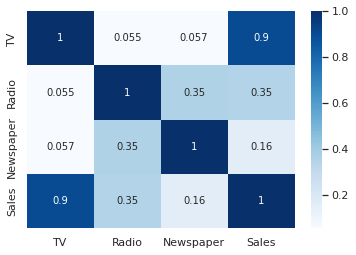

In [7]:
sns.heatmap(data=data.corr(), annot=True, cmap='Blues')

Используя функцию [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) библиотеки sklearn, разбейте данные на обучающую и тестовую выборки. Размер тестовой выборки - 20% от всей выборки.

In [8]:
from sklearn.model_selection import train_test_split
X, Y = data[features], data[target]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

Расскоментирйте код внизу и расставьте строки в правильном порядке с тем чтобы успешно обучить модель линейной регрессии и оценить качество предсказания с помощью R<sup>2</sup>-score

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
model = LinearRegression()
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
r2_score(Y_test, Y_pred)

0.8711899433179275

R<sup>2</sup>-score позвоялет оценить качество предсказание модели в среднем. Диаграмма рассеяния true-predicted дает более детальную информацию о качестве предсказания модели, позволяя оценить величину ошибки для каждой из точек тестовой выборки.

Text(0, 0.5, 'Predicted Sales')

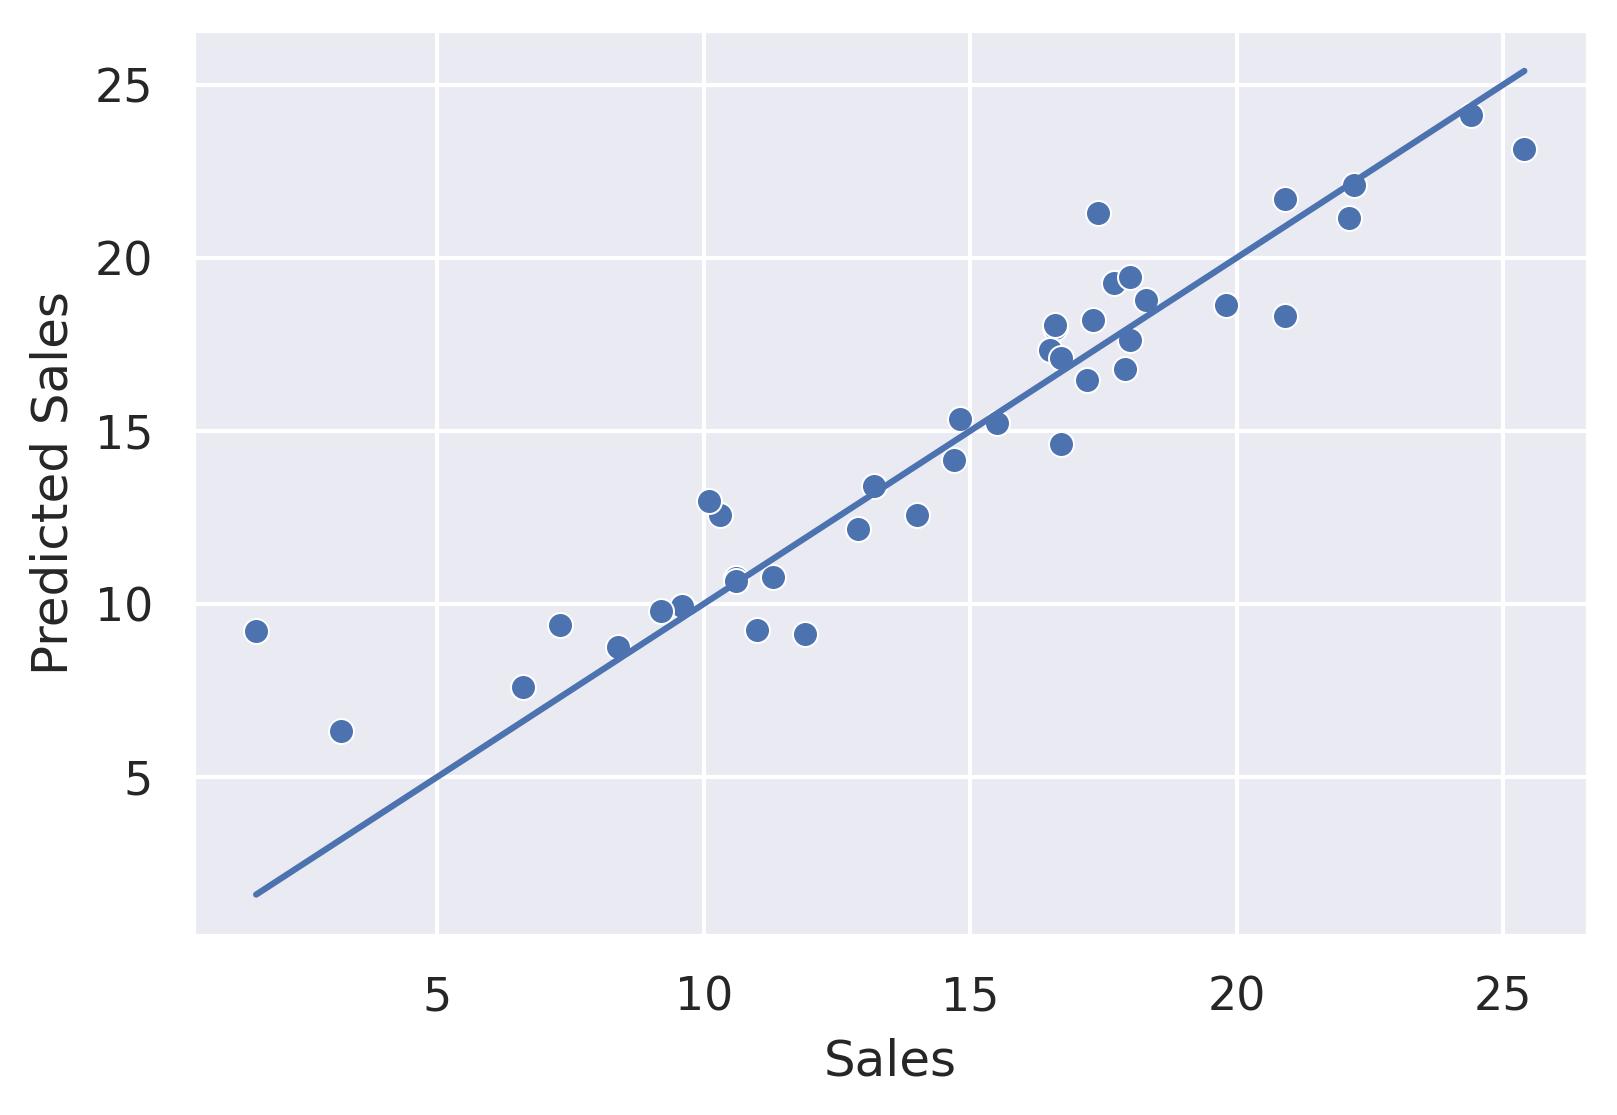

In [10]:
sns.set(rc={'figure.dpi':300})
low, high = np.min(np.minimum(Y_test, Y_pred)), np.max(np.maximum(Y_test, Y_pred))
ax = sns.scatterplot(x=Y_test, y=Y_pred)
sns.lineplot(x=[low, high], y=[low, high], ax=ax)
ax.set_ylabel(f'Predicted {target}')

# Decision tree classifier and overfitting

<img src="img/dt_meme.jpeg" alt="decision tree" style="float: left;"/>

Прочтите данные из файла "data/sales.csv", выведите несколько первых строчек прочитанной таблицы, используя метод [.head](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.head.html) 

In [11]:
data = pd.read_csv("data/sales.csv")
data.head(n=10)

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020
5,6,0,12/7/2009,ADESA,2004,5,MITSUBISHI,GALANT 4C,ES,4D SEDAN ES,...,8149.0,9451.0,NaN,NaN,19638,33619,FL,5600.0,0,594
6,7,0,12/7/2009,ADESA,2004,5,KIA,SPECTRA,EX,4D SEDAN EX,...,6230.0,8603.0,NaN,NaN,19638,33619,FL,4200.0,0,533
7,8,0,12/7/2009,ADESA,2005,4,FORD,TAURUS,SE,4D SEDAN SE,...,6942.0,8242.0,NaN,NaN,19638,33619,FL,4500.0,0,825
8,9,0,12/7/2009,ADESA,2007,2,KIA,SPECTRA,EX,4D SEDAN EX,...,9637.0,10778.0,NaN,NaN,21973,33619,FL,5600.0,0,482
9,10,0,12/7/2009,ADESA,2007,2,FORD,FIVE HUNDRED,SEL,4D SEDAN SEL,...,12580.0,14845.0,NaN,NaN,21973,33619,FL,7700.0,0,1633


Полученная таблица содержит данные о закупках атомобилей. Задача - на основе данных о средней рыночной цене транспортного средства и показаний одометра сделать вывод о том будет ли покупка данного атомобиля выгодной.

In [12]:
target = 'IsBadBuy'
features = ['MMRCurrentRetailAveragePrice', 'VehOdo']

## Missing values issue

Еще один полезный метод датафрейма - `.decribe` - позволяет вывести статистическую информацию о колонках датафрейма. Обратите внимание - в верхней строчке вывода `count` указано число не пропущенных значений для каждой колонки.

In [13]:
data[features + [target]].describe()

,MMRCurrentRetailAveragePrice,VehOdo,IsBadBuy
count,72668.000000,72983.000000,72983.000000
mean,8775.723331,71499.995917,0.122988
std,3090.702941,14578.913128,0.328425
min,0.000000,4825.000000,0.000000
25%,6536.000000,61837.000000,0.000000
50%,8729.000000,73361.000000,0.000000
75%,10911.000000,82436.000000,0.000000
max,39080.000000,115717.000000,1.000000


Общее число строк датафрейма. Сравнивая это число и число заполненных значений для каждой колонки, приходим к выводу, что небольшое число значений признака `MMRCurrentRetailAveragePrice` пропущено

In [14]:
len(data)

72983

Ориентируясь на код предыдущего задания, разбейте датасет на обучающую и тестовую выборку и попрубуйте обучить решающее дерево предсказывать целевой признак. Выполнение кода приведет к ошибке, связанной с присутствием пропусков в данных - большинство моедей не умеют корректоно обработать пропуски.

In [15]:
X, Y = data[features], data[target]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [16]:
data.shape

(72983, 34)

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)
accuracy_score(model.predict(X_test), Y_test)

ValueError: Input contains NaN, infinity or a value too large for dtype('float32').

Исправьте возникающую ошибку за счет удаления строк, в которых значения признаков или целевой переменной отсутствуют.
Вам поможет следующий код  
`data.dropna(your arguments)`


In [18]:
data.dropna(subset=features+[target], inplace=True)

## Overfitting

<img src="img/overfit_meme.jpg" alt="overfitting" width="500" style="float: left;"/>

Вновь попробуйте натренировать модель машинного обучения

In [19]:
X, Y = data[features], data[target]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
model.fit(X_train, Y_train)
accuracy_score(model.predict(X_test), Y_test)

0.7891839823861291

Получившееся качество предсказания кажется достаточно высоким. Но является ли полученный результат оптимальным? Проверим это, меняя гиперпараметр классификатора - максимальную глубину решающего дерева - и сравнивая качоство предсказания на обучающей и тестовой выборке для разных значений параметра

In [20]:
train_q = []
test_q = []
depths = [i for i in range(1, 50)]
early_stop_achieved = False
for d in depths:
    DT = DecisionTreeClassifier(max_depth=d)
    DT.fit(X_train, Y_train)  # train the model
    train_q.append(accuracy_score(Y_train, DT.predict(X_train)))  # quality on the train sample
    test_q.append(accuracy_score(Y_test, DT.predict(X_test)))  # quality on the test sample
    print(f'Depth {d}; train acc - {train_q[-1]}, test acc - {test_q[-1]}')

    if len(test_q) > 1 and not early_stop_achieved:
        if test_q[-1] < test_q[-2]:
            print(f'Early stop has been achieved. The optimal depth is {d-1}')
            early_stop_achieved = True

Depth 1; train acc - 0.8773351223036433, test acc - 0.8752580156873538
Depth 2; train acc - 0.8773351223036433, test acc - 0.8752580156873538
Depth 3; train acc - 0.8776791550555613, test acc - 0.8754644282372368
Depth 4; train acc - 0.8776963566931572, test acc - 0.8755332324205312
Depth 5; train acc - 0.8777651632435408, test acc - 0.8755332324205312
Depth 6; train acc - 0.8782640107338219, test acc - 0.8742259529379386
Early stop has been achieved. The optimal depth is 5
Depth 7; train acc - 0.8789348746000619, test acc - 0.87408834457135
Depth 8; train acc - 0.8797261499294733, test acc - 0.8736755194715838
Depth 9; train acc - 0.8809130629235903, test acc - 0.87250584835558
Depth 10; train acc - 0.882839646334331, test acc - 0.870716939589927
Depth 11; train acc - 0.8852650772353529, test acc - 0.8694784642906289
Depth 12; train acc - 0.8877249114115664, test acc - 0.8676207513416816
Depth 13; train acc - 0.8909072143668078, test acc - 0.8655566258428512
Depth 14; train acc - 0.89

Корректно отрисуйте зависимсоть точности предсказания на обучающей и тестовой выборке от максимальной глубины решающего дерева, используя функцию [sns.lineplot](https://seaborn.pydata.org/generated/seaborn.lineplot.html). График наглядно демонстрирует эффект переобучения модели - с увеличением сложности модели повышается точность на обучающей выборке, но на тестовой точность падает. Происходит это потому, что сложная модель слишком сильно подстраивается под точки обучающей выборки, выстраивая неправдоподобно сложную аппроксимацию целевой функции.

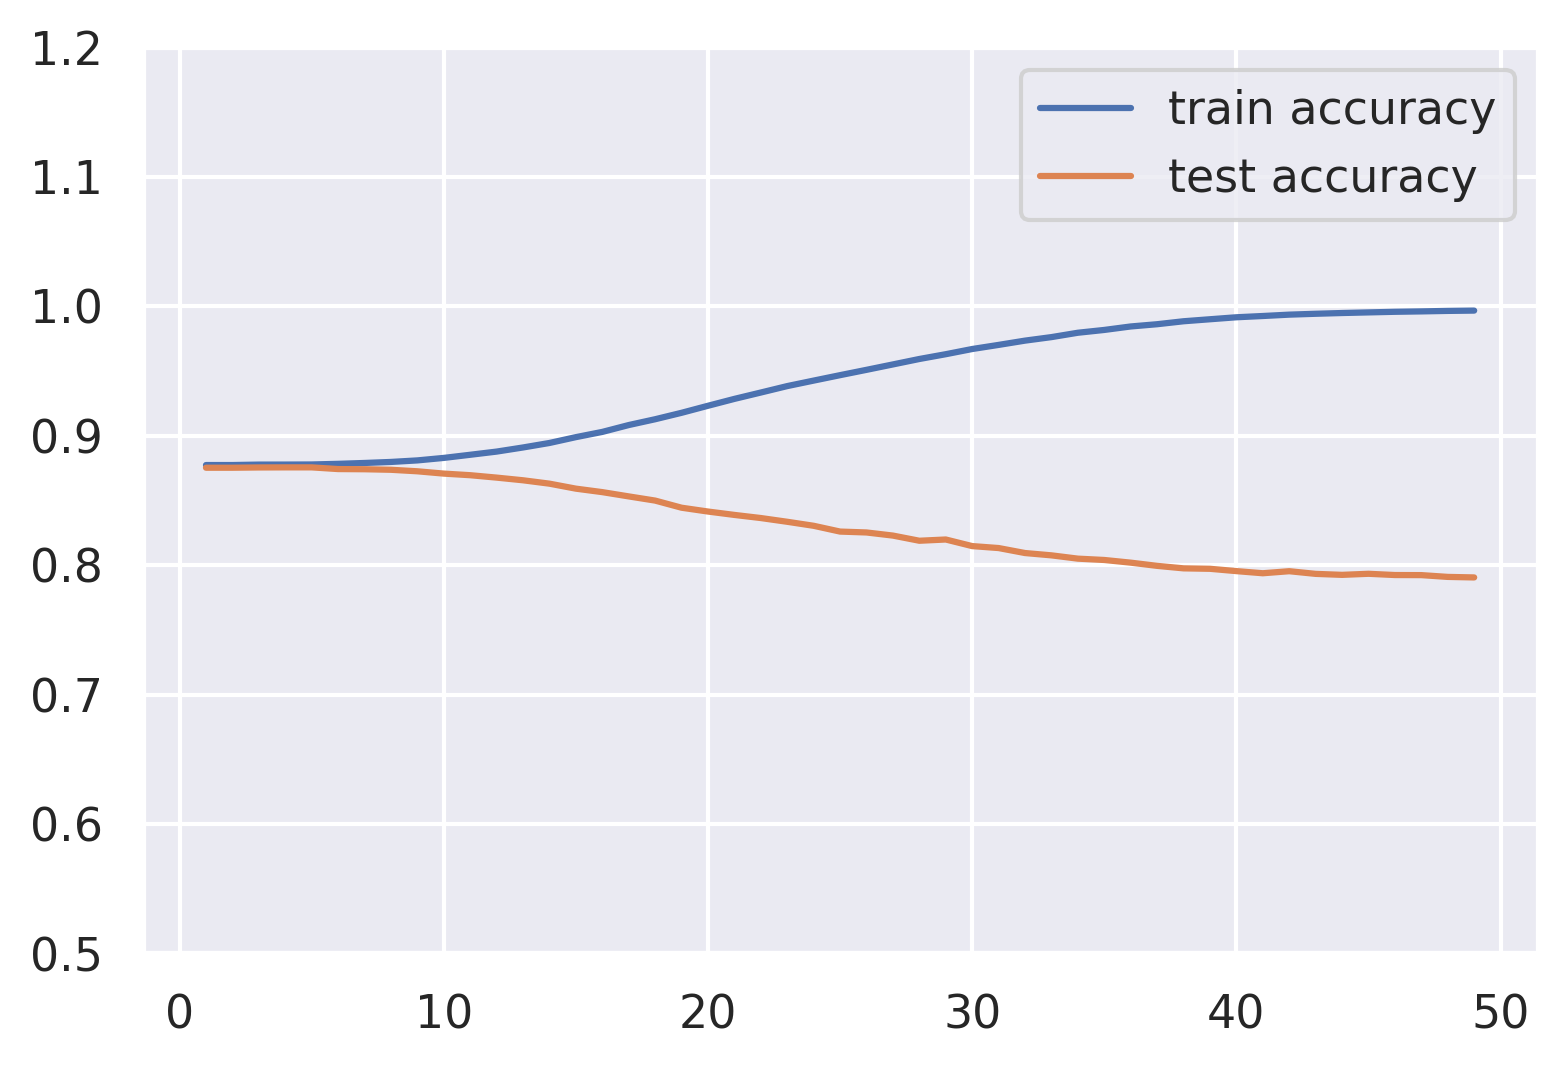

In [21]:
x_arr = depths
fig, ax = plt.subplots()
sns.lineplot(x=x_arr, y=train_q, label='train accuracy')
sns.lineplot(x=x_arr, y=test_q, label='test accuracy')
ax.set_ylim(0.5, 1.2)
ax.legend()

Тепловая карта предсказания решающего дерева с оптимальной глубиной

accuracy_score on test: 0.8755332324205312


/home/mikl/.local/lib/python3.9/site-packages/sklearn/base.py:441: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


(4825.0, 115717.0)

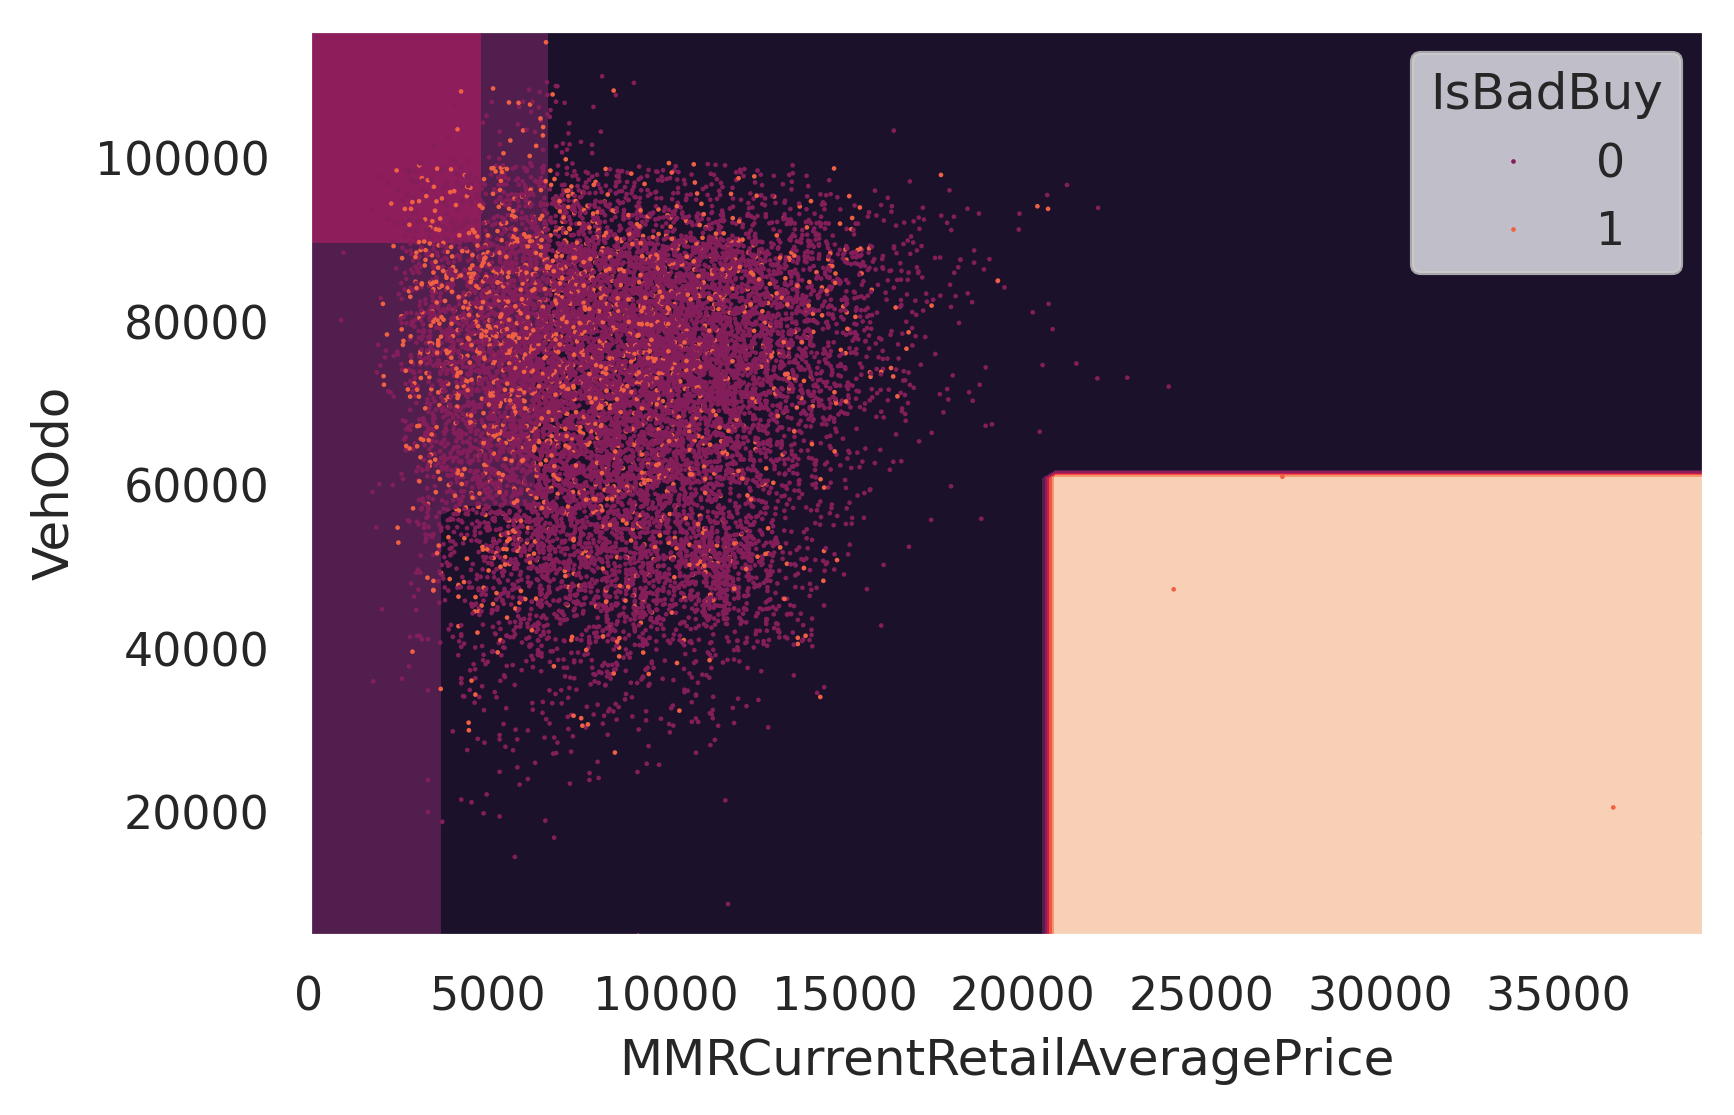

In [22]:
xname=features[0]; yname=features[1]
model = DecisionTreeClassifier(max_depth=4)

fig, ax = plt.subplots()
model.fit(X_train, Y_train)
print(f'accuracy_score on test: {accuracy_score(Y_test, model.predict(X_test))}')
xlim = (data[xname].min(), data[xname].max())
ylim = (data[yname].min(), data[yname].max())
grid_x = np.linspace(*xlim, 100)
grid_y = np.linspace(*ylim, 100)
xx, yy = np.meshgrid(grid_x, grid_y)
grid = np.c_[xx.ravel(), yy.ravel()]
prediction = model.predict_proba(grid)[:, 1].reshape(xx.shape)
ax.contourf(xx, yy, prediction, cmap=sns.color_palette("rocket", as_cmap=True))

ax = sns.scatterplot(data=X_test.join(Y_test), x=xname, y=yname, hue=target, palette="rocket", ax=ax,
                     marker='.', linewidth=0, s=5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)


Тепловая карта предсказания переобученного решающего дерева

accuracy_score on test: 0.7915921288014311


/home/mikl/.local/lib/python3.9/site-packages/sklearn/base.py:441: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


(4825.0, 115717.0)

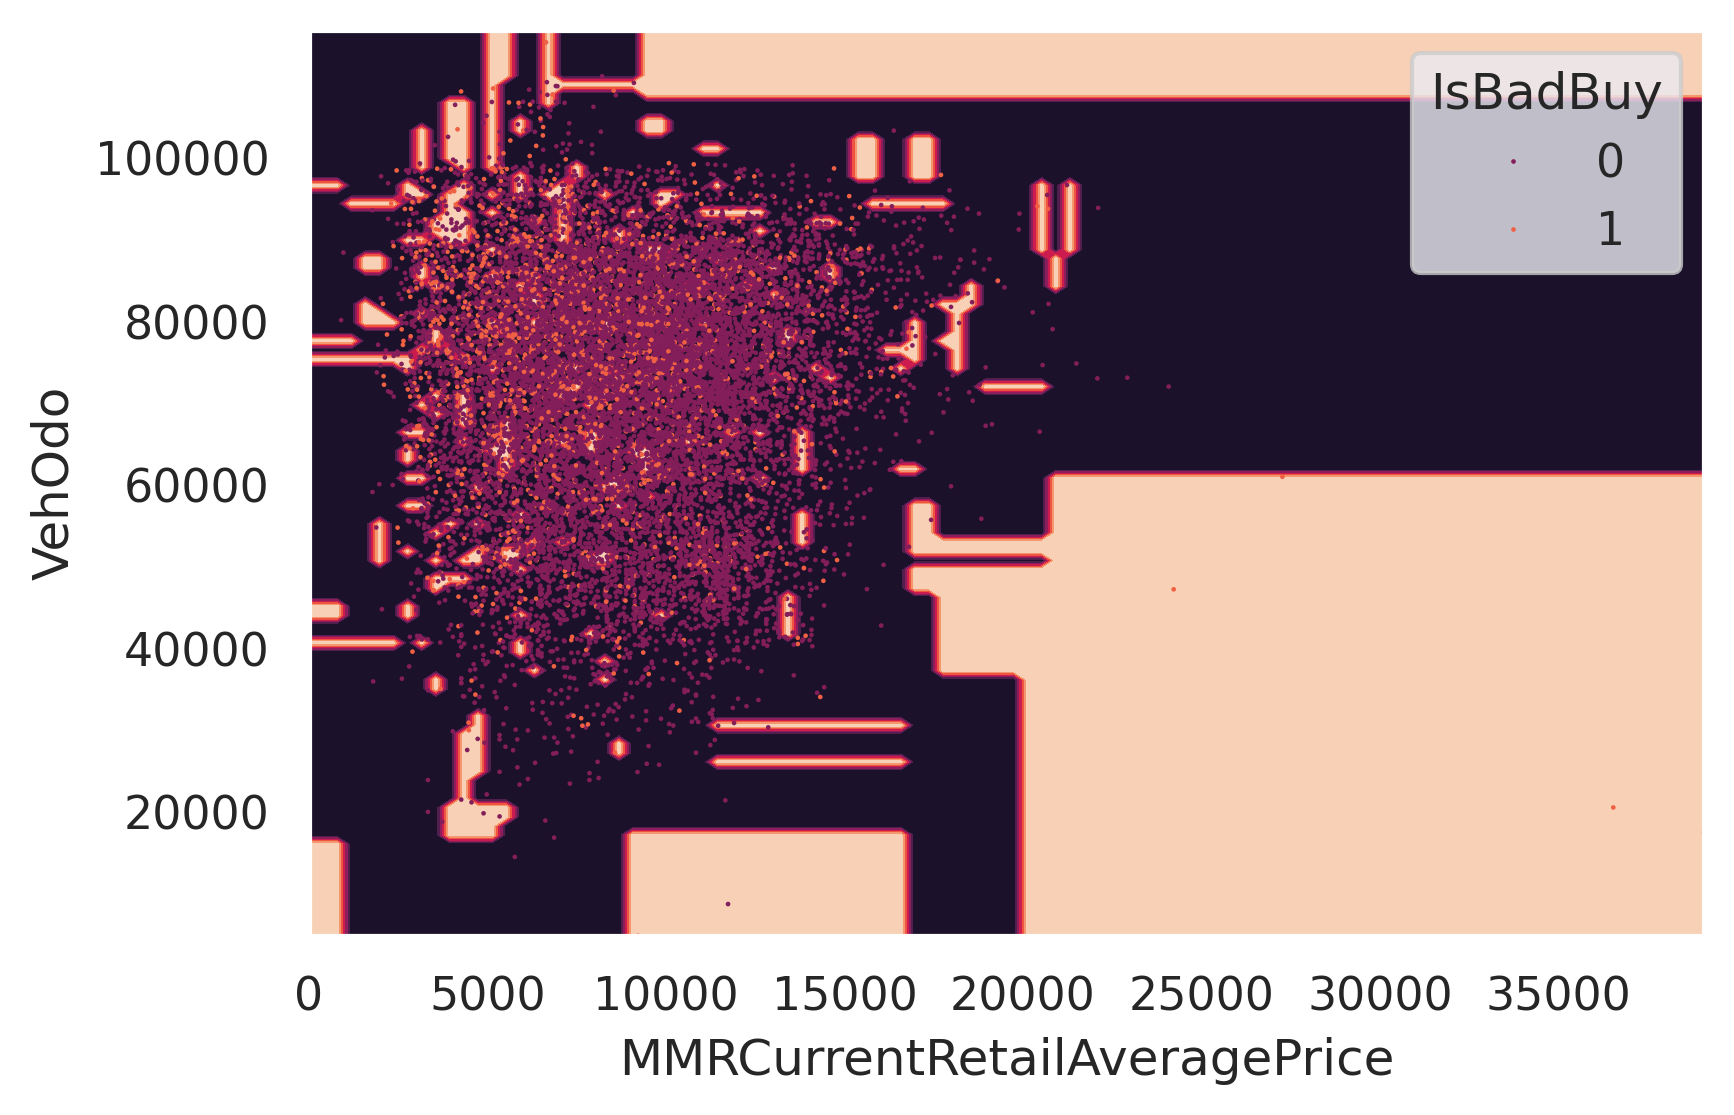

In [23]:
model = DecisionTreeClassifier(max_depth=depths[-1])

fig, ax = plt.subplots()
model.fit(X_train, Y_train)
print(f'accuracy_score on test: {accuracy_score(Y_test, model.predict(X_test))}')
prediction = model.predict_proba(grid)[:, 1].reshape(xx.shape)
ax.contourf(xx, yy, prediction, cmap=sns.color_palette("rocket", as_cmap=True))

ax = sns.scatterplot(data=X_test.join(Y_test), x=xname, y=yname, hue=target, palette="rocket", ax=ax,
                    marker='.', linewidth=0, s=5)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# Feature selection

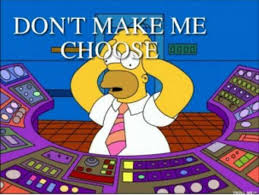

Прочтите и отобразите данные из файла "data/diffusion.csv"

In [24]:
data = pd.read_csv("data/diffusion.csv")
data

,Material compositions 1,Material compositions 2,E_regression,Hop activation barrier,valence_composition_average,phi_composition_average,NdValence_composition_average,MiracleRadius_composition_average,GSestFCClatcnt_composition_average,SecondIonizationEnergy_composition_average,...,Site2_MendeleevNumber,Site2_ElasticModulus,Site2_Electronegativity,Site2_AtomicWeight,Site2_HeatFusion,Site2_SpecificHeatCapacity,Site2_AtomicRadii,Site2_ThermalExpansionCoefficient,Site2_BCCefflatcnt,Site2_AtomicVolume
0,Ag,Ag,0.000000,-0.365590,2.0,4.350,10.0,144.0,4.027313,21.4900,...,65,80.0,1.93,107.868200,11.30,0.235,1.444,18.9,6.375951,17.075648
1,Ag,Co,-0.090142,-0.675263,2.5,4.725,8.5,134.5,3.737485,19.2750,...,58,208.0,1.88,58.933195,16.20,0.421,1.253,13.0,5.507318,10.995861
2,Ag,Cr,0.259139,-0.047690,4.0,4.500,7.5,137.0,3.788936,18.9950,...,49,259.0,1.66,51.996100,21.00,0.449,1.249,4.9,5.632801,12.092937
3,Ag,Cu,-0.022200,-0.428459,2.0,4.400,10.0,135.0,3.782567,20.8910,...,64,124.0,1.90,63.546000,13.60,0.385,1.278,16.5,5.617632,11.829942
4,Ag,Fe,0.317672,0.081529,4.0,4.640,8.0,134.5,3.764269,18.8350,...,55,211.0,1.83,55.845000,13.81,0.449,1.241,11.8,5.557847,11.777365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,Zr,Nb,-0.067020,-0.478007,4.5,3.750,3.0,150.5,4.350534,13.7250,...,47,104.0,1.60,92.906380,30.00,0.265,1.429,7.3,6.625794,18.002133
404,Zr,Ta,0.153850,-0.054726,4.5,3.750,2.5,151.5,4.348236,6.5650,...,48,183.0,1.50,180.947880,36.57,0.140,1.430,6.3,6.618497,18.046730
405,Zr,Ti,0.248110,-0.022476,4.0,3.625,2.0,150.0,4.291886,13.3550,...,43,110.0,1.54,47.867000,14.15,0.523,1.448,8.6,6.458833,17.636317
406,Zr,Hf,0.204140,-0.104201,4.0,3.525,2.0,158.0,4.494239,14.0275,...,45,139.0,1.30,178.490000,27.20,0.140,1.564,5.9,7.046762,22.268711


Целевая переменная - "E_regression"

<Axes: xlabel='E_regression', ylabel='Count'>

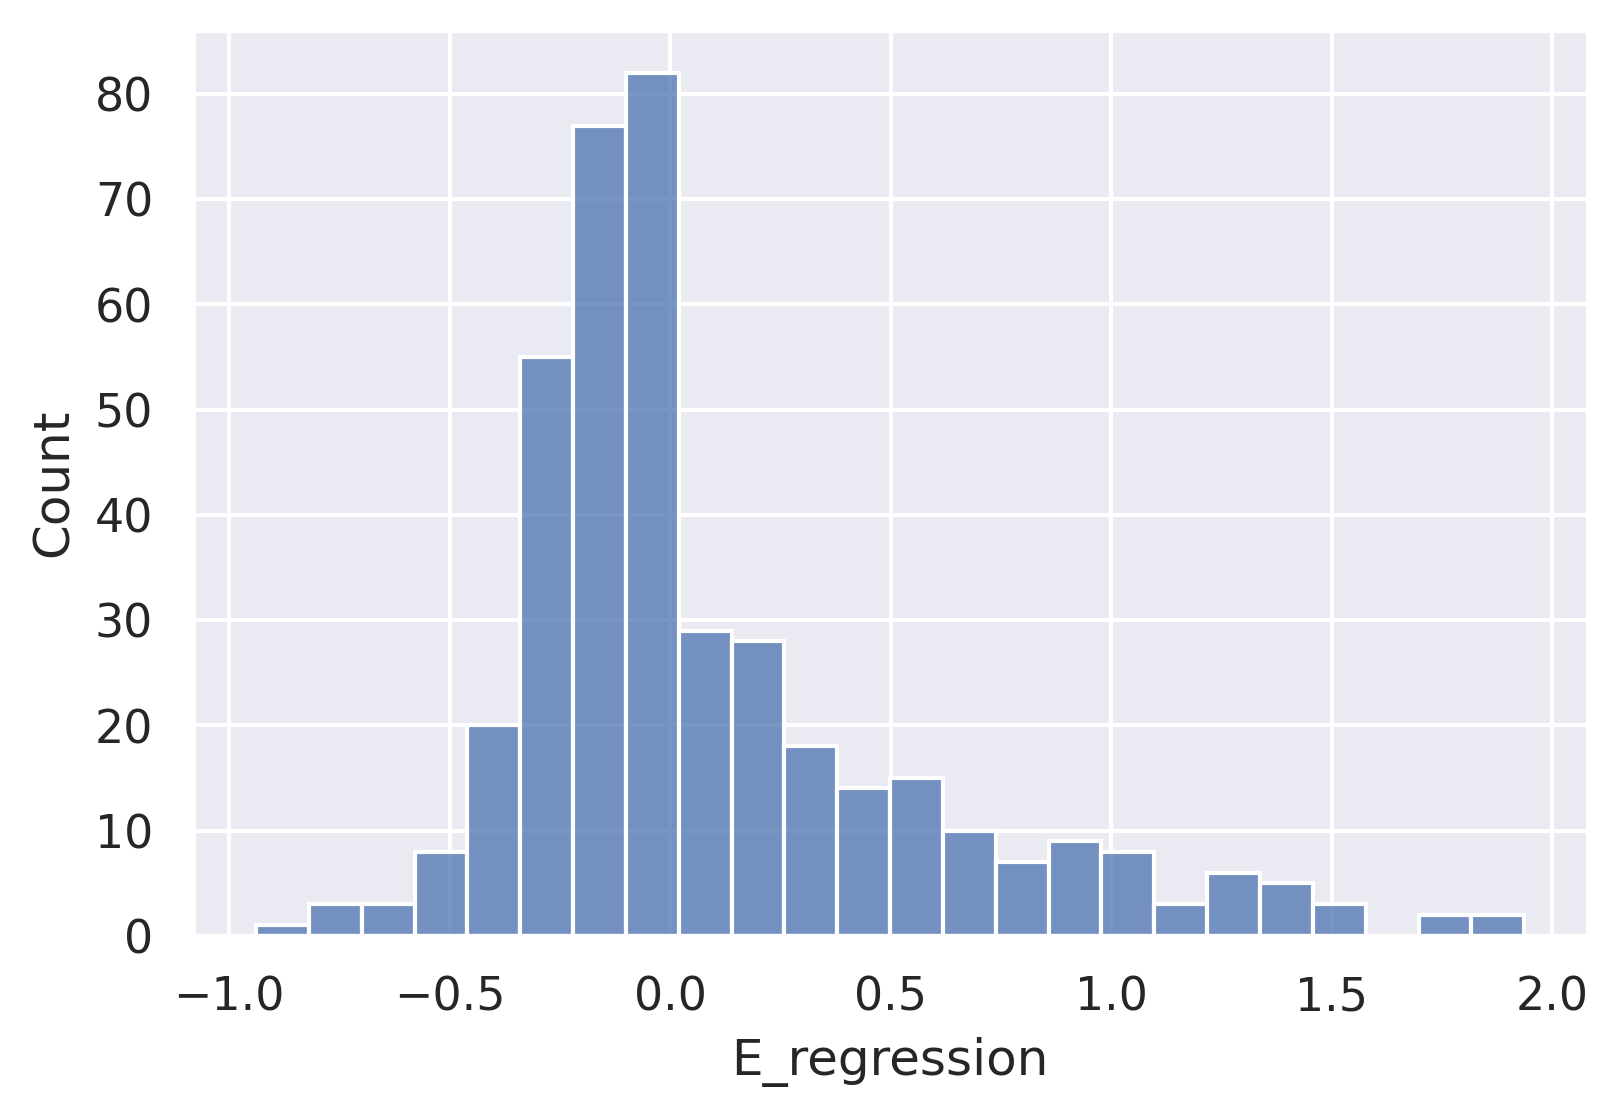

In [25]:
target = 'E_regression'
sns.histplot(data[target])

Все остальные колонки числового типа - признаки

In [26]:
from pandas.api.types import is_numeric_dtype
features = [col for col in data.columns if col != target and is_numeric_dtype(data[col])]

Пробуем предсказать целевое свойство методом ближайших соседей

In [27]:
X, Y = data[features], data[target]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,
                                                   random_state=0)

In [28]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=10)
model.fit(X_train, Y_train)
Y_pred = model.predict(X_test)
r2_score(Y_test, Y_pred)

/home/mikl/.local/lib/python3.9/site-packages/sklearn/base.py:441: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


0.30946194517714043

Одним из распространенных способов увеличения качества предсказания моделей является уменьшение размерности данных. В частности - предсказание по нескольким наиболее важным признакам. Существует множество способов определения важности признаков, мы воспользуемся самыми быстрыми и простыми из них.  
Отберите 5 наиболее важных признаков с помощью метода `f_regression`. Для отбора признаков полезной будет функция `numpy.argsort`, позволяющая произвести сортировку по ключу

In [29]:
from sklearn.feature_selection import f_regression
fscore = f_regression(X, Y)[0]  # get f_score from X, Y
num_best = 3
best_features_f = np.array(features)[np.argsort(fscore)][-num_best:]  # select best features with key sort
best_features_f

array(['Site2_GSenergy_pa', 'Site2_MeltingT', 'Hop activation barrier'],
      dtype='<U47')

Обновите обучающую и тестовую выборки, вновь натренируйте и оцените модель

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(data[best_features_f], data[target], test_size=0.2)
model.fit(X_train, Y_train)
r2_score(model.predict(X_test), Y_test)

/home/mikl/.local/lib/python3.9/site-packages/sklearn/base.py:441: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


-0.2400600272833986

Отберите признаки с помощью mutual_info_regression 

In [31]:
from sklearn.feature_selection import mutual_info_regression
mi = mutual_info_regression(X, Y)
num_best = 3
best_features_mi = np.array(features)[np.argsort(mi)][-num_best:]
best_features_mi

array(['Site2_AtomicNumber', 'Site2_AtomicWeight',
       'Hop activation barrier'], dtype='<U47')

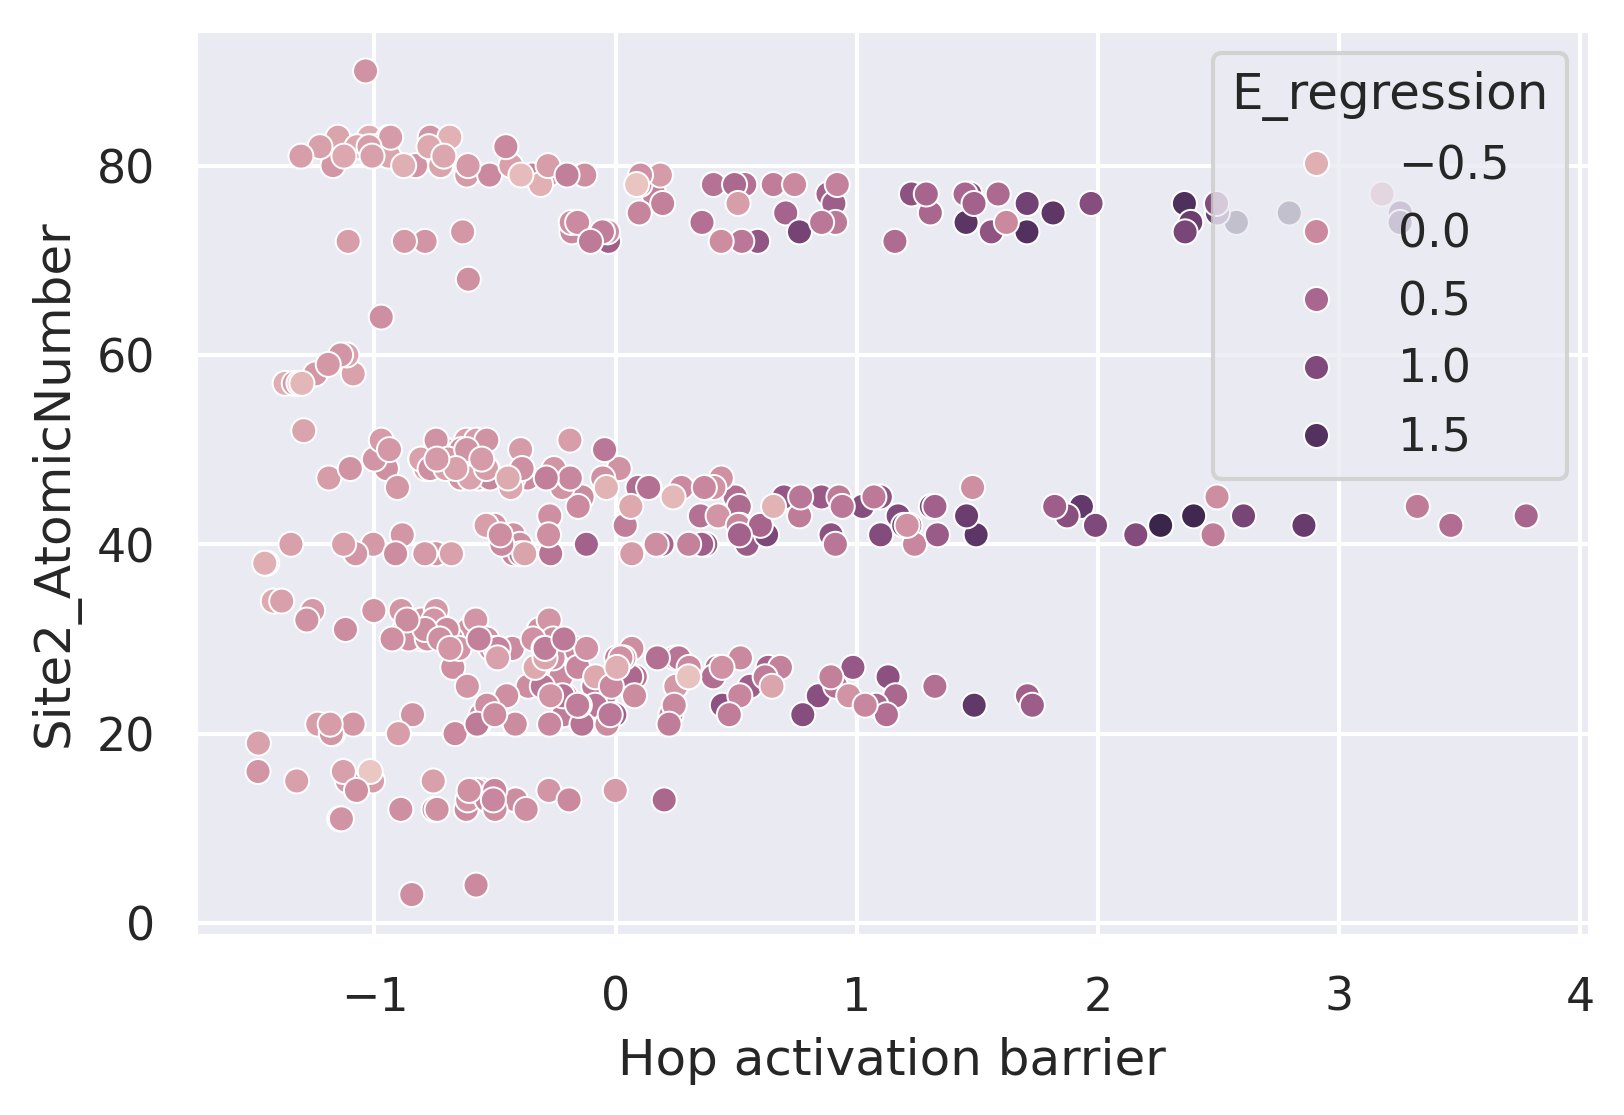

In [32]:
x='Hop activation barrier'
ax = sns.scatterplot(data=data, x=x, y="Site2_AtomicNumber", hue=target)

Еще раз обновите обучающую и тестовую выборки, натренируйте и оцените модель

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(data[best_features_mi], data[target], test_size=0.2)
model.fit(X_train, Y_train)
r2_score(model.predict(X_test), Y_test)

/home/mikl/.local/lib/python3.9/site-packages/sklearn/base.py:441: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


-0.1262410564353782

Отбор признаков на этот раз не привел к увеличению качетсва предсказаний. Это напоминание о том, что многие методы машинного обучения не являются универсальными - хорошо работают на одних данных и не работают на других.

# Outliers

<img src="img/outliers_meme.png" alt="outliers" style="float: left;"/>

Прочтите и отобразите данные из файла "data/mobile_price.csv"

In [34]:
data = pd.read_csv("data/mobile_price.csv")
data

,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,4.5,6.0,128.0,6.18,35,15.0,3800,18999
...,...,...,...,...,...,...,...,...
802,3.8,6.0,32.0,4.54,48,12.0,2800,1299
803,4.1,8.0,64.0,4.54,64,8.0,2500,1390
804,4.4,3.0,32.0,6.20,48,1.0,3800,9790
805,3.7,10.0,32.0,4.50,64,8.0,3500,799


Полученная таблица содержит данные о мобильных телефонах. Задача - найти зависимость цены гаджета от его параметров (память, разрешение камеры, заряд аккумулятора, etc).

In [35]:
target = 'Price'
features = [col for col in data.columns if col != target and is_numeric_dtype(data[col])]

In [36]:
X, Y = data[features], data[target]

Натренируйте и оцените ансамблевую модель `ExtraTreesRegressor`.\
На этот раз не используйте стандартную полседовательность `train_test_split` - `fit` - `predict`. Вместо этого воспользуйтесь одной единственной функцией `cross_val_predict`. Сохораните результат работы функции в переменную `Y_pred`.

In [37]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import cross_val_predict
model = ExtraTreesRegressor()
Y_pred = cross_val_predict(model, X, Y)
r2_score(Y, Y_pred)

0.8911337394450785

Диаграмма рассеняния true-predicted

Text(0, 0.5, 'Predicted Price')

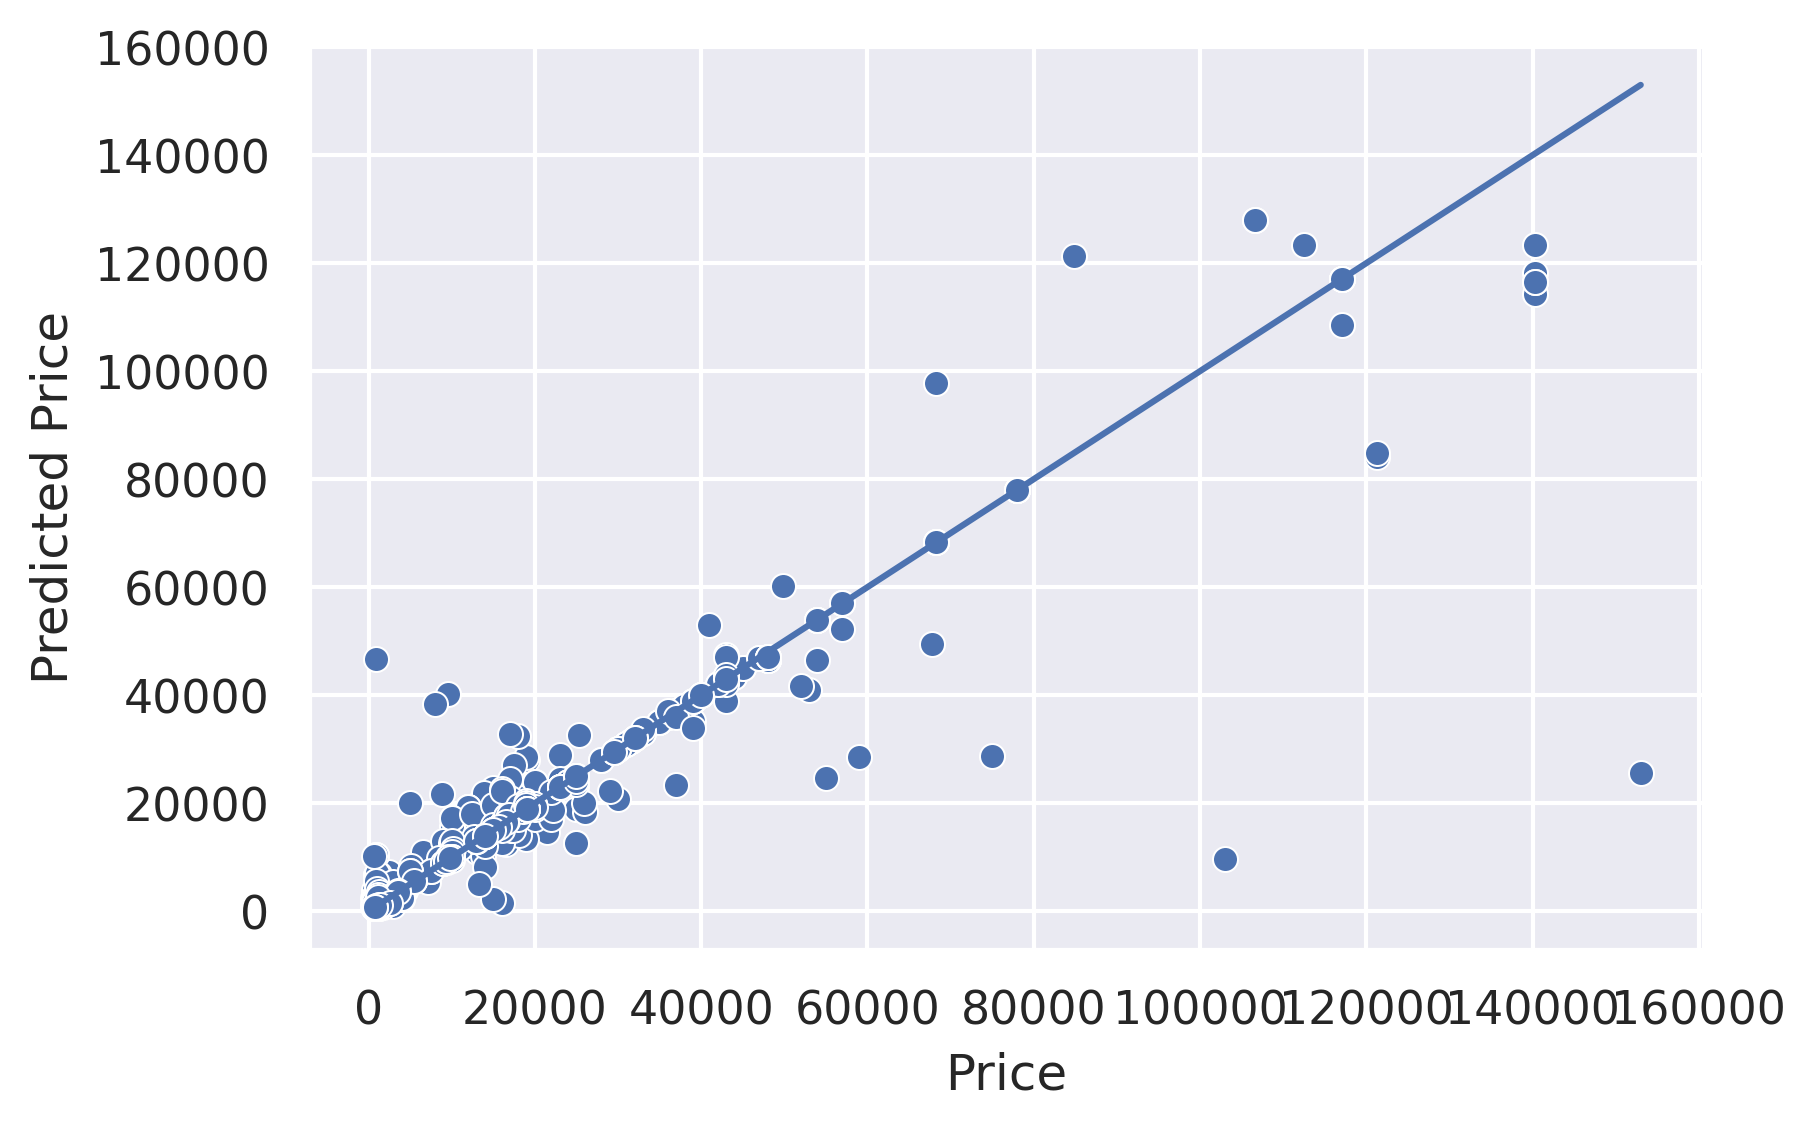

In [38]:
low, high = np.min(np.minimum(Y, Y_pred)), np.max(np.maximum(Y, Y_pred))
ax = sns.scatterplot(x=Y, y=Y_pred)
sns.lineplot(x=[low, high], y=[low, high], ax=ax)
ax.set_ylabel(f'Predicted {target}')

Равномерно ли распределена величина ошибки среди точек выборки?

<Axes: ylabel='Price'>

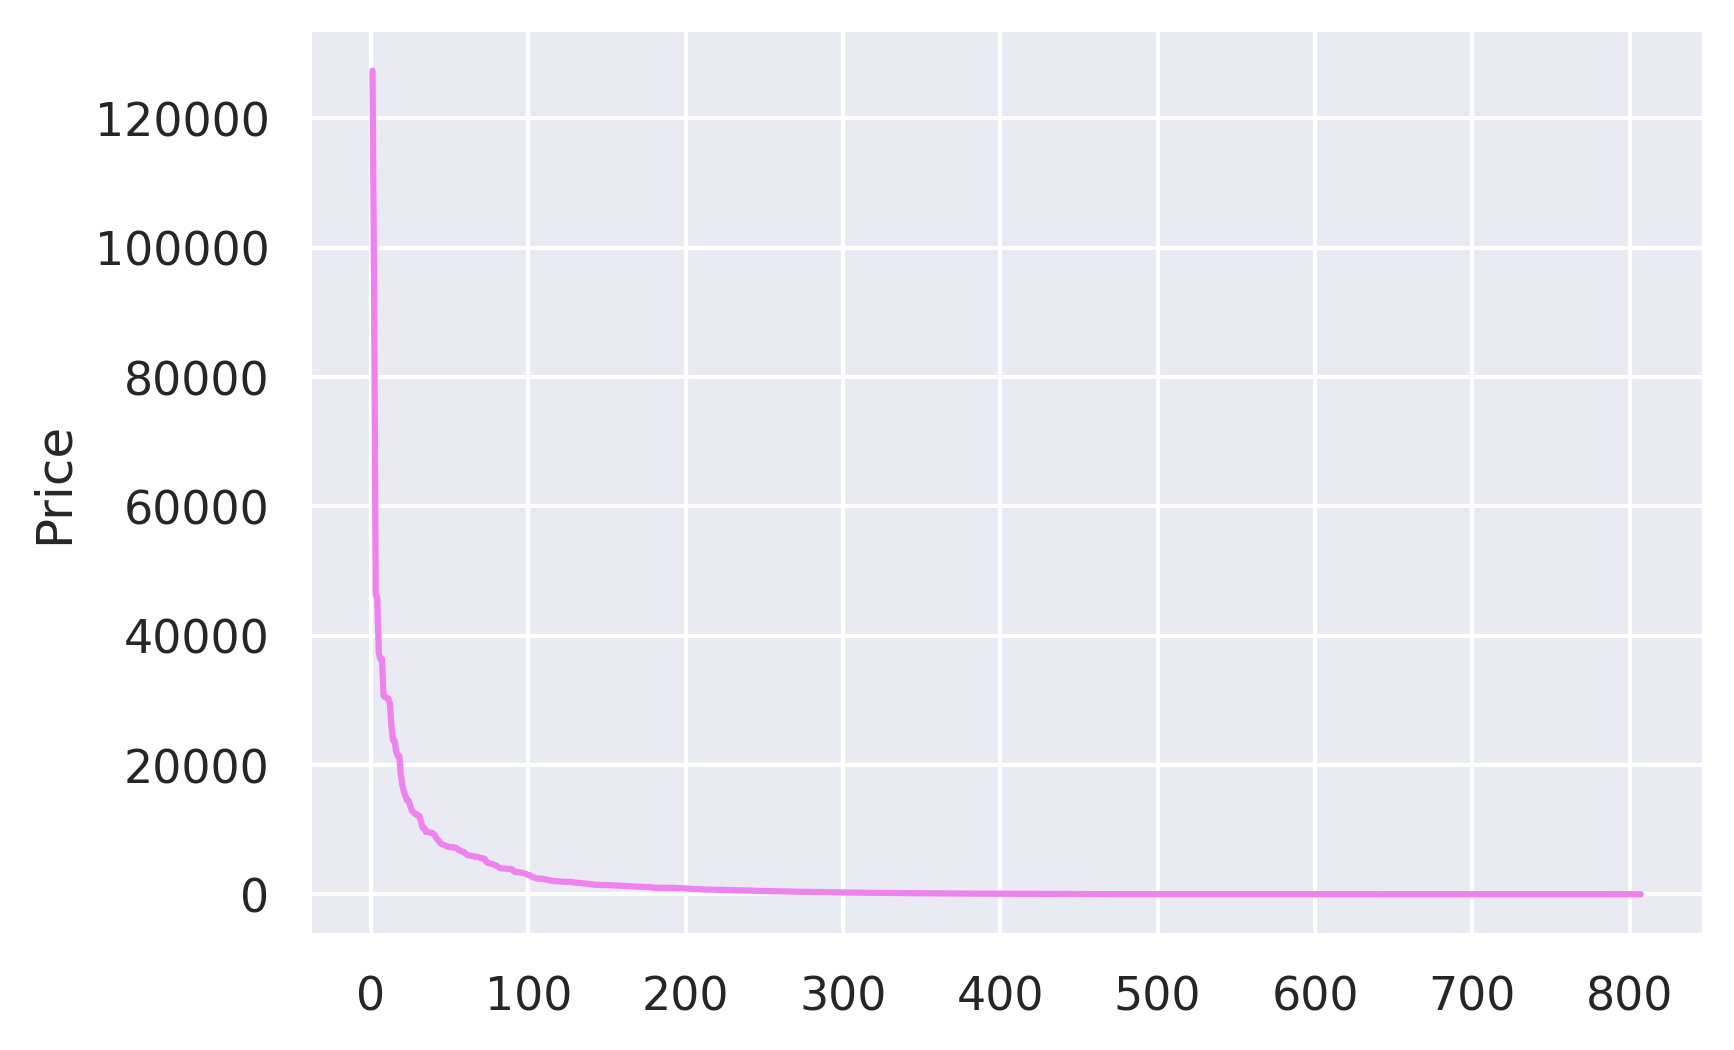

In [39]:
abs_error = np.abs(Y - Y_pred)
argsort = np.argsort(abs_error)[::-1]
sns.lineplot(x=np.arange(Y.shape[0]) + 1, y=abs_error[abs_error.index[argsort]], color='violet')

Отберите все точки датасета кроме 60 с наибольшей ошибкой. Используйте метод датафрейма `.loc`. Вновь сделайте предсказание методом `cross_val_predict`

In [40]:
less_error_idx = abs_error.index[argsort][60:]
data = data.loc[less_error_idx, :]

In [41]:
X, Y = data[features], data[target]
model = ExtraTreesRegressor()
Y_pred = cross_val_predict(model, X, Y)
r2_score(Y, Y_pred)

0.9692414079925397

Text(0, 0.5, 'Predicted Price')

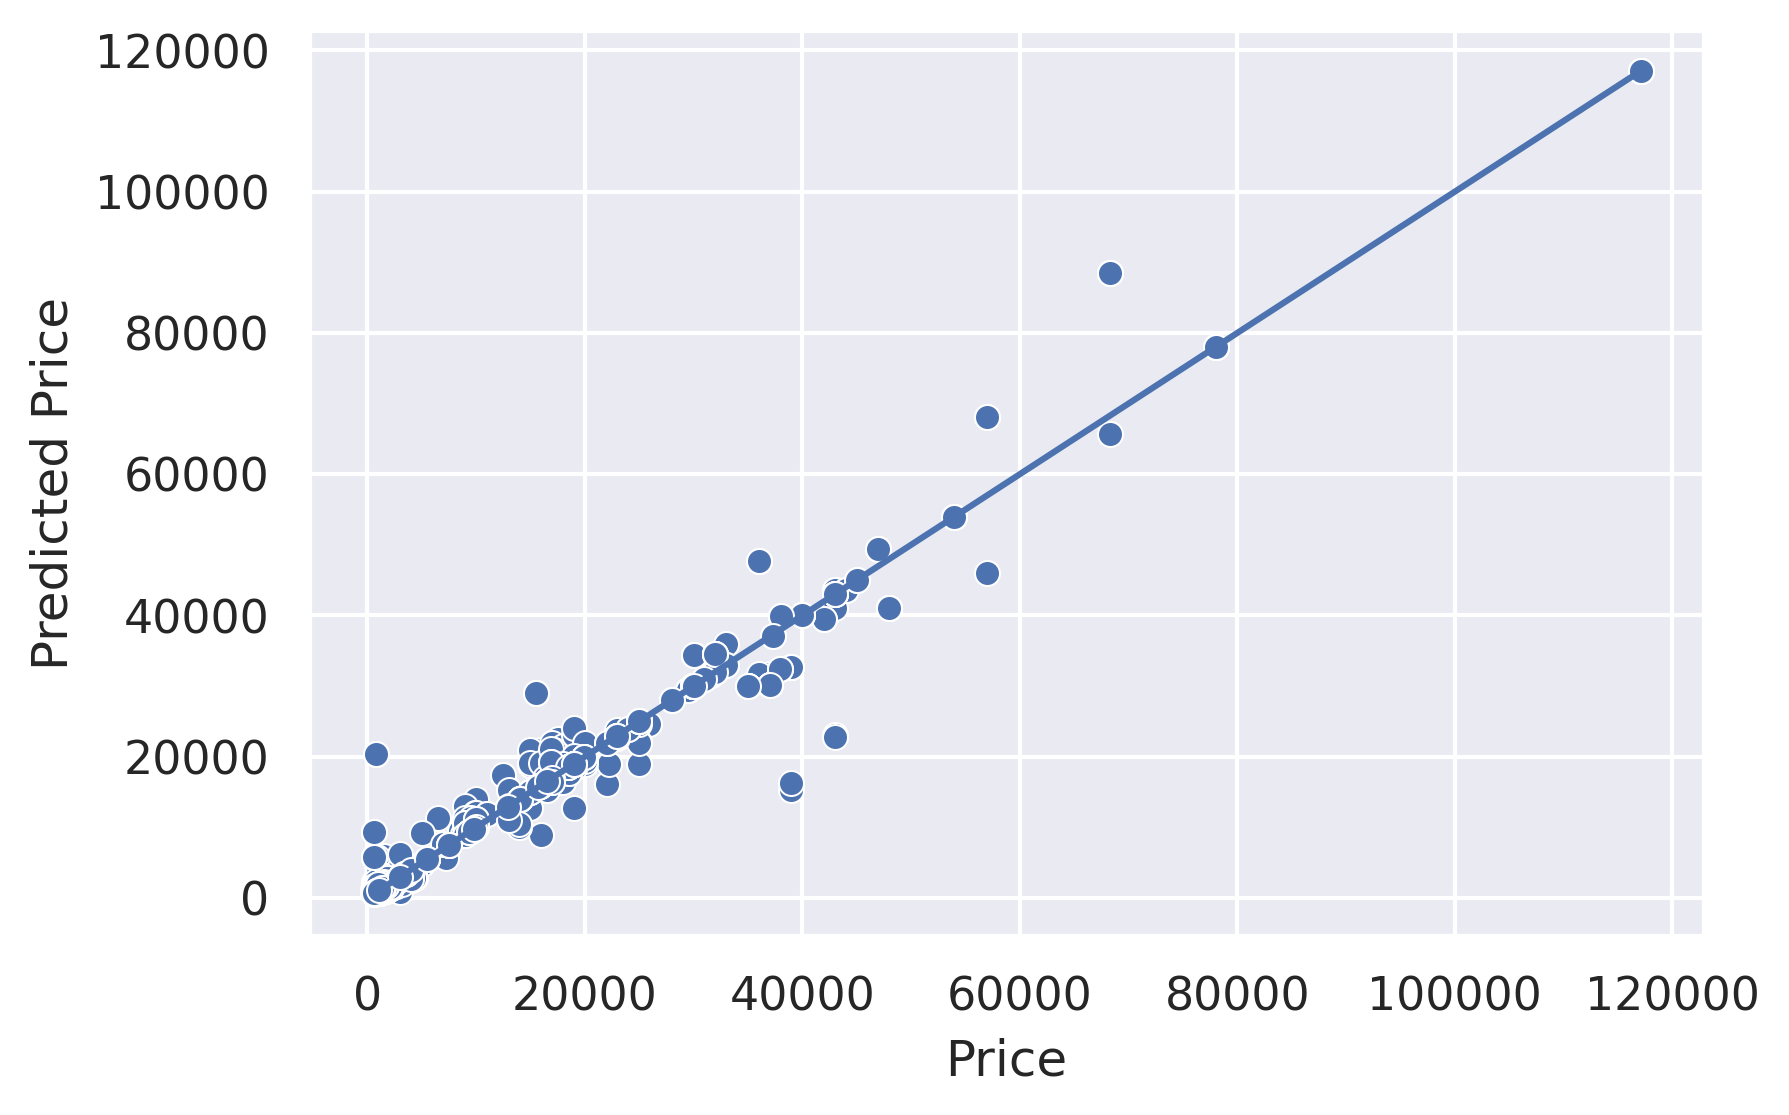

In [42]:
low, high = np.min(np.minimum(Y, Y_pred)), np.max(np.maximum(Y, Y_pred))
ax = sns.scatterplot(x=Y, y=Y_pred)
sns.lineplot(x=[low, high], y=[low, high], ax=ax)
ax.set_ylabel(f'Predicted {target}')

# Feature engineering

Прочтите данные о пассажирах Титаника. Посмотрите на данные. Какой тип данных содержится в каждой колонке? Какие колонки можно сразу использовать в качетсве признаков, а какие не будут приняты моделями в качестве входа?

In [43]:
data = pd.read_csv('data/titanic_partial.csv')
data

,PassengerId,Survived,Pclass,Name,Age,Ticket,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",22.0,A/5 21171,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,PC 17599,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",26.0,STON/O2. 3101282,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,113803,C123,S
4,5,0,3,"Allen, Mr. William Henry",35.0,373450,NaN,S
...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,211536,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,112053,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,W./C. 6607,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",26.0,111369,C148,C


Задача - установить зависимость выживания пассажира Титаника от известных параметров

In [44]:
target = 'Survived'
features = ['Pclass', 'Name', 'Age', 'Cabin', 'Embarked']

Используя методы `.describe` и `.nunique` выведите статистическую информацию по колонкам датасета. О каких дополнительных сложностях предупреждает полученная информация?

In [45]:
data = data[features + [target]]
data.describe(include='all')

,Pclass,Name,Age,Cabin,Embarked,Survived
count,891.000000,891,714.000000,204,889,891.000000
unique,NaN,891,NaN,147,3,NaN
top,NaN,"Braund, Mr. Owen Harris",NaN,B96 B98,S,NaN
freq,NaN,1,NaN,4,644,NaN
mean,2.308642,NaN,29.699118,NaN,NaN,0.383838
std,0.836071,NaN,14.526497,NaN,NaN,0.486592
min,1.000000,NaN,0.420000,NaN,NaN,0.000000
25%,2.000000,NaN,20.125000,NaN,NaN,0.000000
50%,3.000000,NaN,28.000000,NaN,NaN,0.000000
75%,3.000000,NaN,38.000000,NaN,NaN,1.000000


In [46]:
data.nunique(axis=0)

Pclass        3
Name        891
Age          88
Cabin       147
Embarked      3
Survived      2
dtype: int64

Выведите уникальные значения призака 'Cabin'

In [47]:
data.Cabin.unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

## Process Age 

Признак "Age" является числовым, однако, для лучшей обработки пропущенных значений и увеличения гибкости модели мы преобразуем его в категориальный с отдельной категорией для пропущенных значений.  
С помощью метода `.fillna` заполните пропущенные значения признака "Age" любым значением меньше 0.

In [48]:
data['Age'] = data.Age.fillna(-5.)
data['Age'] = data['Age'].map(lambda x: x // 10 * 10).astype('int')

/tmp/ipykernel_13859/3459185268.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age'] = data.Age.fillna(-5.)
/tmp/ipykernel_13859/3459185268.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Age'] = data['Age'].map(lambda x: x // 10 * 10).astype('int')


## Process Cabin

Следующий ниже код позволяет разбить номер кабины на первую букву и циферную часть. Первая буква номера будет выступать в качестве категориального признака. Цифреная часть будет числовым признаком.  
С помощью метода `.fillna` заполните пропущенные значения признака "Cabin".

In [49]:
data['Cabin'] = data.Cabin.fillna('N')
data['CabinFirstLetter'] = data.Cabin.map(lambda s: s[0])
data['CabinNumber'] = data.Cabin.map(lambda s: ''.join(filter(lambda c: c in '0123456789 ', s)))
data['CabinNumber'] = data.CabinNumber.map(lambda s: s if s else '0').map(lambda s: [w for w in s.split() if w][0]).astype('int')
features.remove('Cabin')
features.extend(('CabinNumber', ))

/tmp/ipykernel_13859/1888782241.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cabin'] = data.Cabin.fillna('N')
/tmp/ipykernel_13859/1888782241.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['CabinFirstLetter'] = data.Cabin.map(lambda s: s[0])


Пробуем визуализировать зависимость целевой переменной от новых признаков.

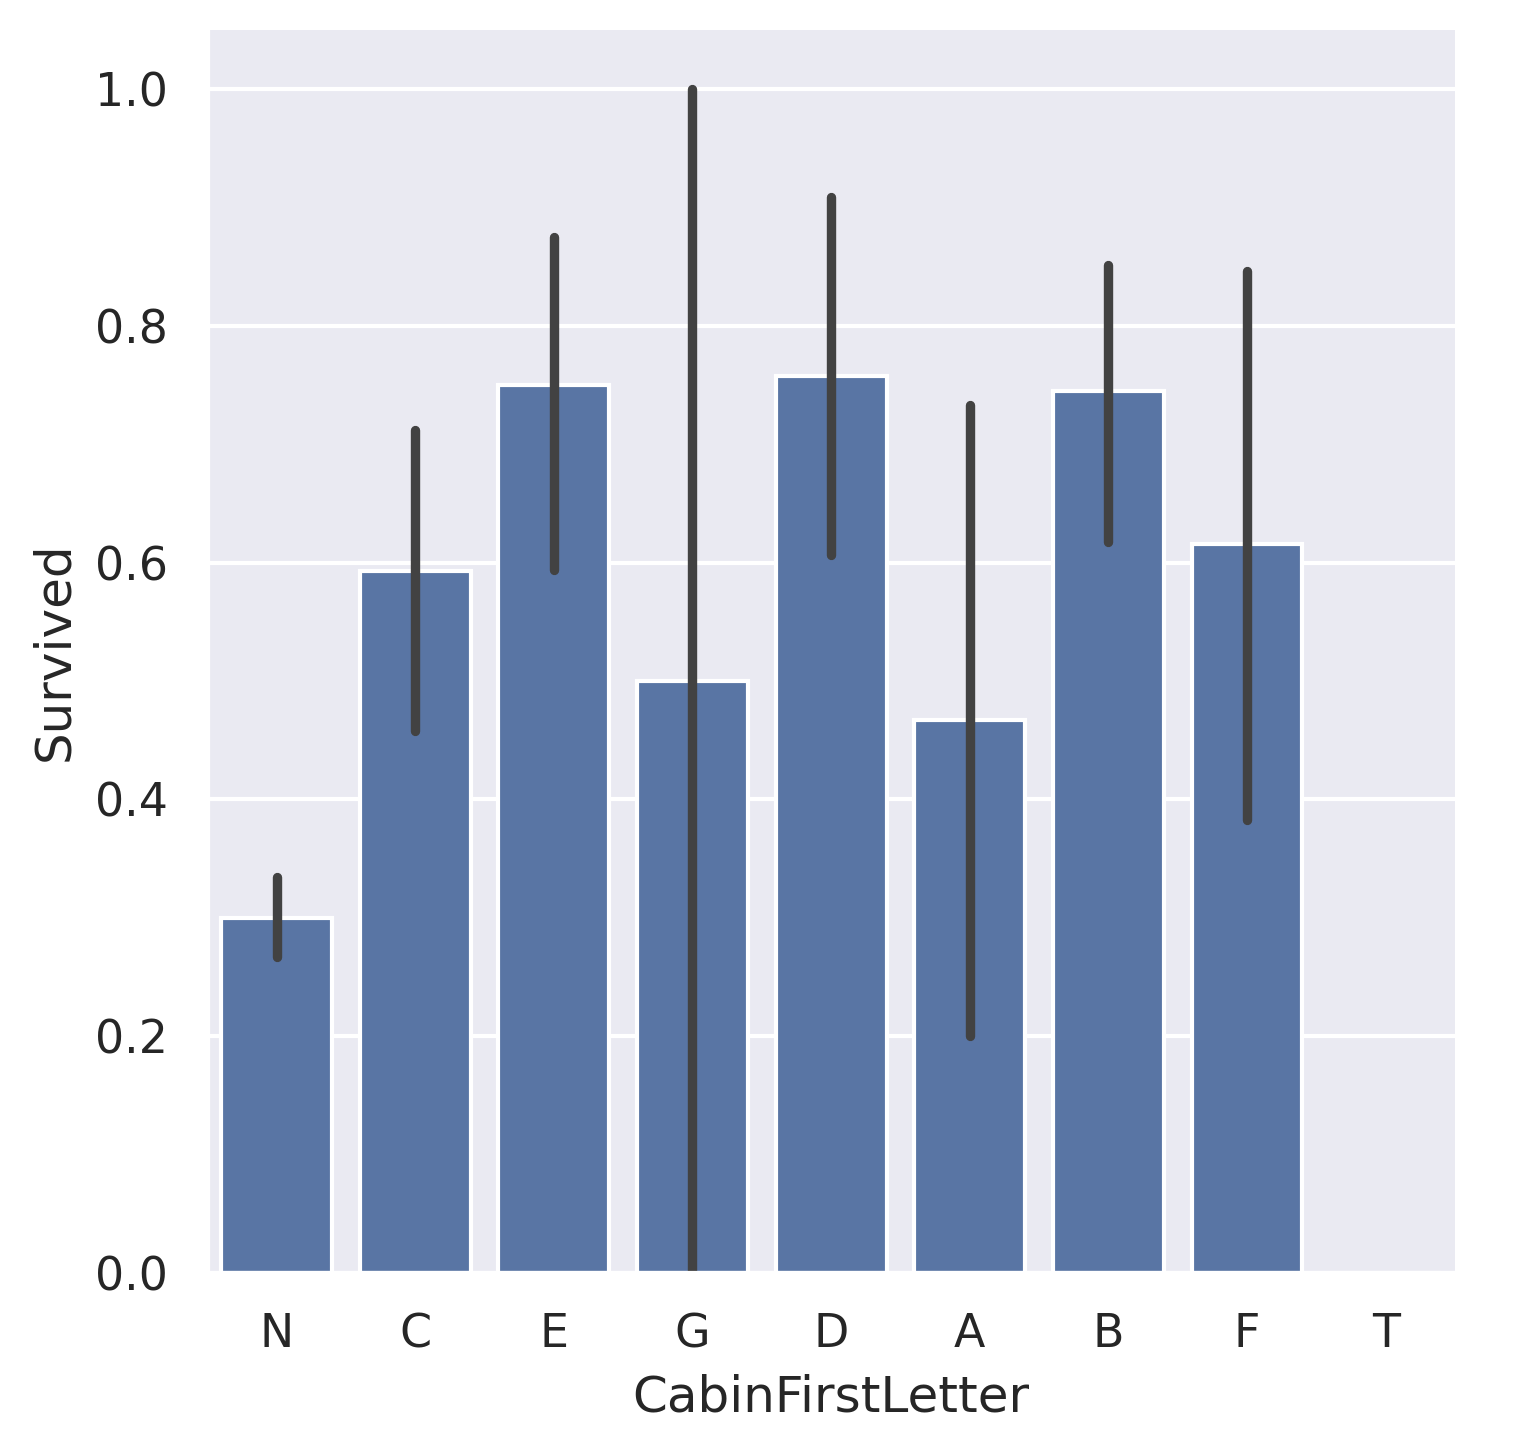

In [50]:
sns.catplot(x="CabinFirstLetter", y=target, data=data, kind='bar')

<Axes: xlabel='Survived', ylabel='CabinNumber'>

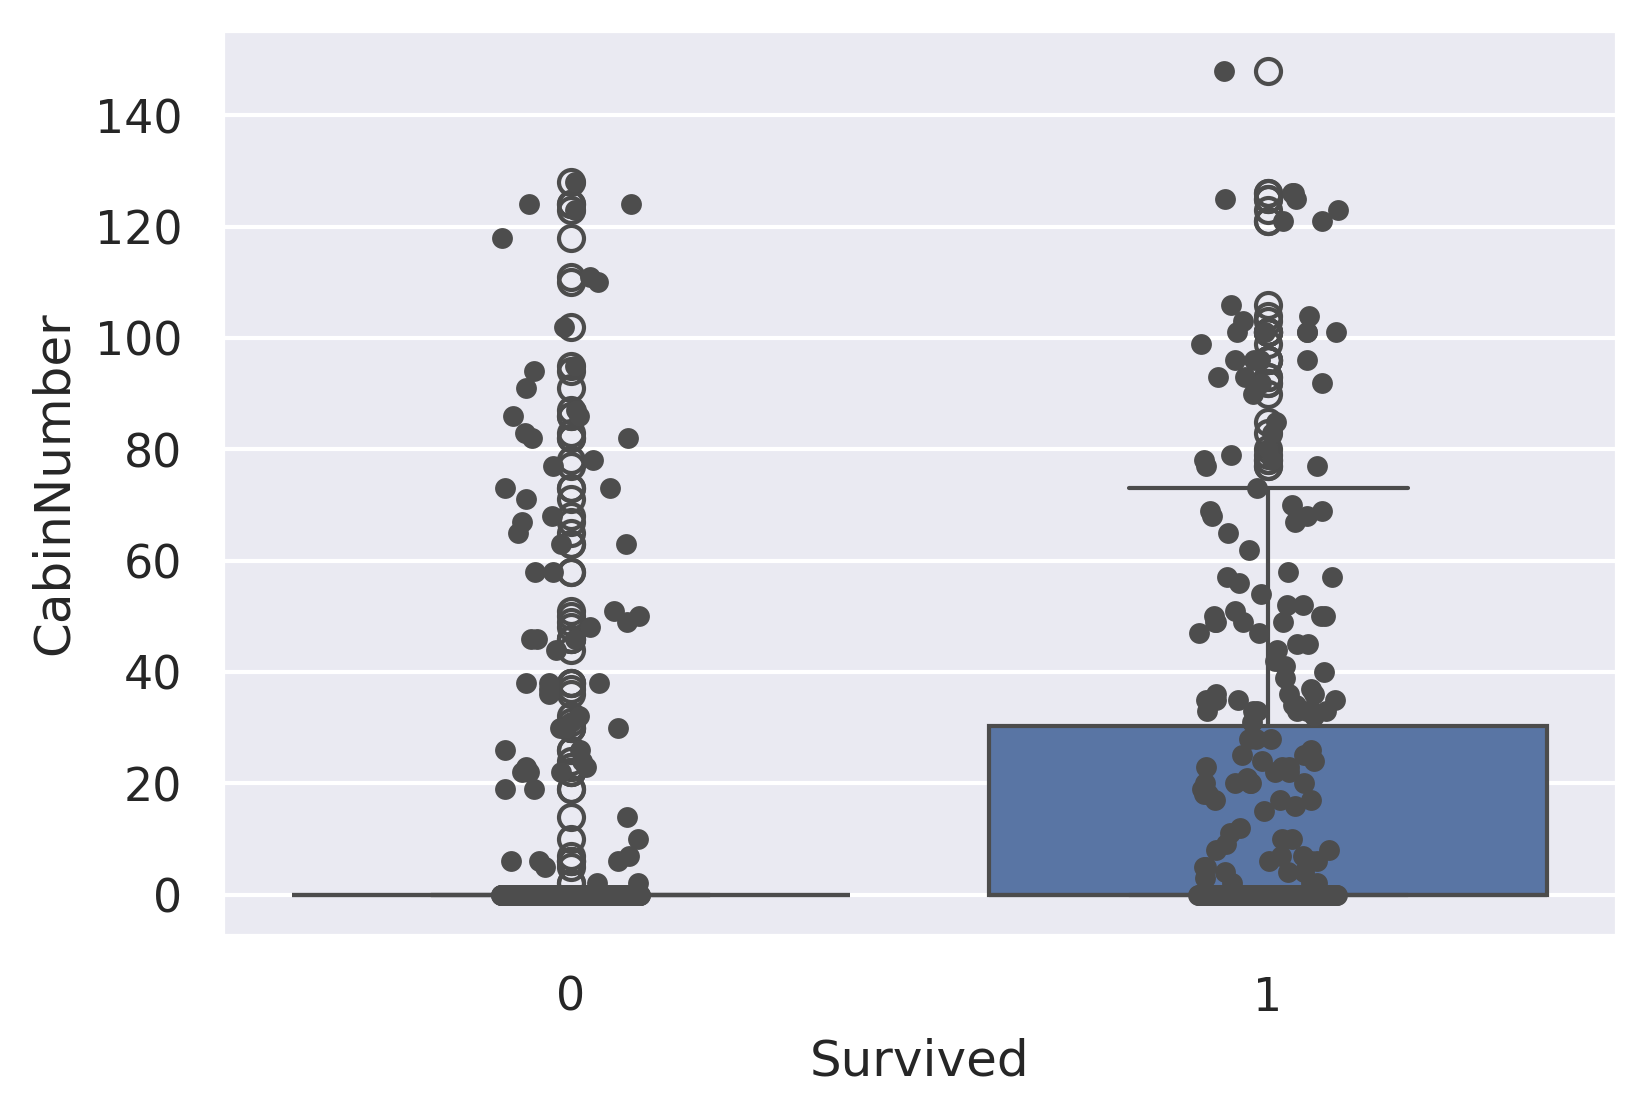

In [51]:
ax = sns.boxplot(x=target, y="CabinNumber", data=data)
sns.stripplot(x=target, y="CabinNumber", data=data, color=".3", ax=ax)

Какие выводы можно сделать по полученным графикам? Имеется ли зависимость между полученными нами признаками и целевой переменной?

## Process Name

Самый простой способ обработки текстового признака - использовать метод bag-of-words (сумка слов). Суть метода состоит в составлении словаря слов, встречающихся в текстовых значениях. Для каждого слова из словаря создается отдельный признак. Значение признака равно 1 если слово встречается в текстовом значении и 0 в противном случае. Имеет смысл добавлять в словарь не все слова, а лишь те что втречаются в достаточно большом числе текстов.  
Правильным образом вызовите метод `fit_transform` у объекта `vectorizer` чтобы сгенерировать признаки методом bag-of-words из имен пассажиров "Титаника". После вызова примените метод `.toarray` чтобы получить новую матрицу признаков из текста в правильном формате. Присвойте эту матрицу в переменную `NameFeatures`.

In [52]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=12, binary=True)
NameFeatures = vectorizer.fit_transform(data['Name']).toarray()
vectorizer.get_feature_names_out()

array(['alfred', 'anna', 'arthur', 'charles', 'edward', 'elizabeth',
       'frederick', 'george', 'henry', 'james', 'johan', 'john', 'joseph',
       'margaret', 'mary', 'master', 'miss', 'mr', 'mrs', 'richard',
       'samuel', 'thomas', 'william'], dtype=object)

Используя метод датафрейма `.join` присоедините матрицу признаков `NameFeatures` к имеющимся данным `data`

In [53]:
NameFeatures = pd.DataFrame(data=NameFeatures, columns=vectorizer.get_feature_names_out())
NameFeatures.columns = NameFeatures.columns.map(lambda s: f'Name_{s}')
data = data.join(NameFeatures)
features.remove('Name')
features.extend(NameFeatures.columns)

## One-hot encoding

Стандартным методом обработки категориальных признаков является one-hot-encoding. Суть метода состоит в том что для каждой категории категориального признака вводится новый отдельный признак. Значение признака для кажой категории равно 1 если точка ей соответствует и 0 в противном случае.

In [54]:
cols_to_one_hot = ('Pclass', 'Embarked', 'Age', 'CabinFirstLetter')
for col in ('Pclass', 'Embarked', 'Age'):
    features.remove(col)

Расскоментирйте код внизу и расставьте строки в правильном порядке с тем чтобы успешно применить one-hot encoding к категориальным признакам из списка

In [55]:
oh_data = pd.DataFrame(index=data.index)
for col in cols_to_one_hot:
    oh_data = oh_data.join(pd.get_dummies(data[col], prefix=col).astype('float'))
oh_cols_train = oh_data.columns.to_list()
features.extend(oh_cols_train)
data = data.join(oh_data)
data.head()

,Pclass,Name,Age,Cabin,Embarked,Survived,CabinFirstLetter,CabinNumber,Name_alfred,Name_anna,...,Age_80,CabinFirstLetter_A,CabinFirstLetter_B,CabinFirstLetter_C,CabinFirstLetter_D,CabinFirstLetter_E,CabinFirstLetter_F,CabinFirstLetter_G,CabinFirstLetter_N,CabinFirstLetter_T
0,3,"Braund, Mr. Owen Harris",20,N,S,0,N,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",30,C85,C,1,C,85,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,"Heikkinen, Miss. Laina",20,N,S,1,N,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",30,C123,S,1,C,123,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,"Allen, Mr. William Henry",30,N,S,0,N,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Modeling

Натренируйте модель `LogisticRegressionCV` на полученных признаках

In [56]:
X, Y = data[features], data[target]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [57]:
from sklearn.linear_model import LogisticRegressionCV
model = LogisticRegressionCV()
model.fit(X_train, Y_train)
accuracy_score(model.predict(X_test), Y_test)

/home/mikl/.local/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/mikl/.local/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n

/home/mikl/.local/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/mikl/.local/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n

0.7932960893854749

# Design of experiment. Grid, LHS and adaptive sampling

<img src="img/exp_meme.jpg" alt="experiment" style="float: left;"/>

В конце, как полагается, мы возвращаемся к началу. До сих пор мы рассматривали наши данные как нечто заранее фиксированное, с чем нам предстоит работать в том виде, в каком оно есть. Теперь отойдем на шаг назад и представим себе, что у нас есть целевая переменная и набор экспериментальных параметров, зависимость целевой переменной от которых мы хотим исследовать с помощью методов машинного обучения. Мы должны сгенерировать данные для обучения.    
Существует множество методов генерации выборки. Эти методы различаются по эффективности между собой - в том смысле что разные методы позволяют извлечь разное количество информации из одного и того же числа экспериментов. В этом разделе мы рассмотрим три метода - простая сетка, метод латтинского гиперкуба и адаптивный семплинг.

In [58]:
!pip install pyDOE2
!pip install --upgrade minlpe

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [59]:
ndim = 3
dimlims = (-5., 5.)

Разница между методами будет лучше всего видна в том случае если от некоторых параметров результат эксперимента не зависит (зависит слабо). Если по методу простой сетки в этой ситуации мы по нескольку раз будем генерировать один и тот же результат, то метод латинского гиперкуба гарантирует, что число уникальных значений каждого признака равно числу точек выборки, и что распределение этих уникальных значений равномерно. Таким образом получается избежать дублирования экспериментов.

In [60]:
def func(x1, x2, x3):
    return 0.2 * x1 ** 3 - 0.5 * x2 ** 2

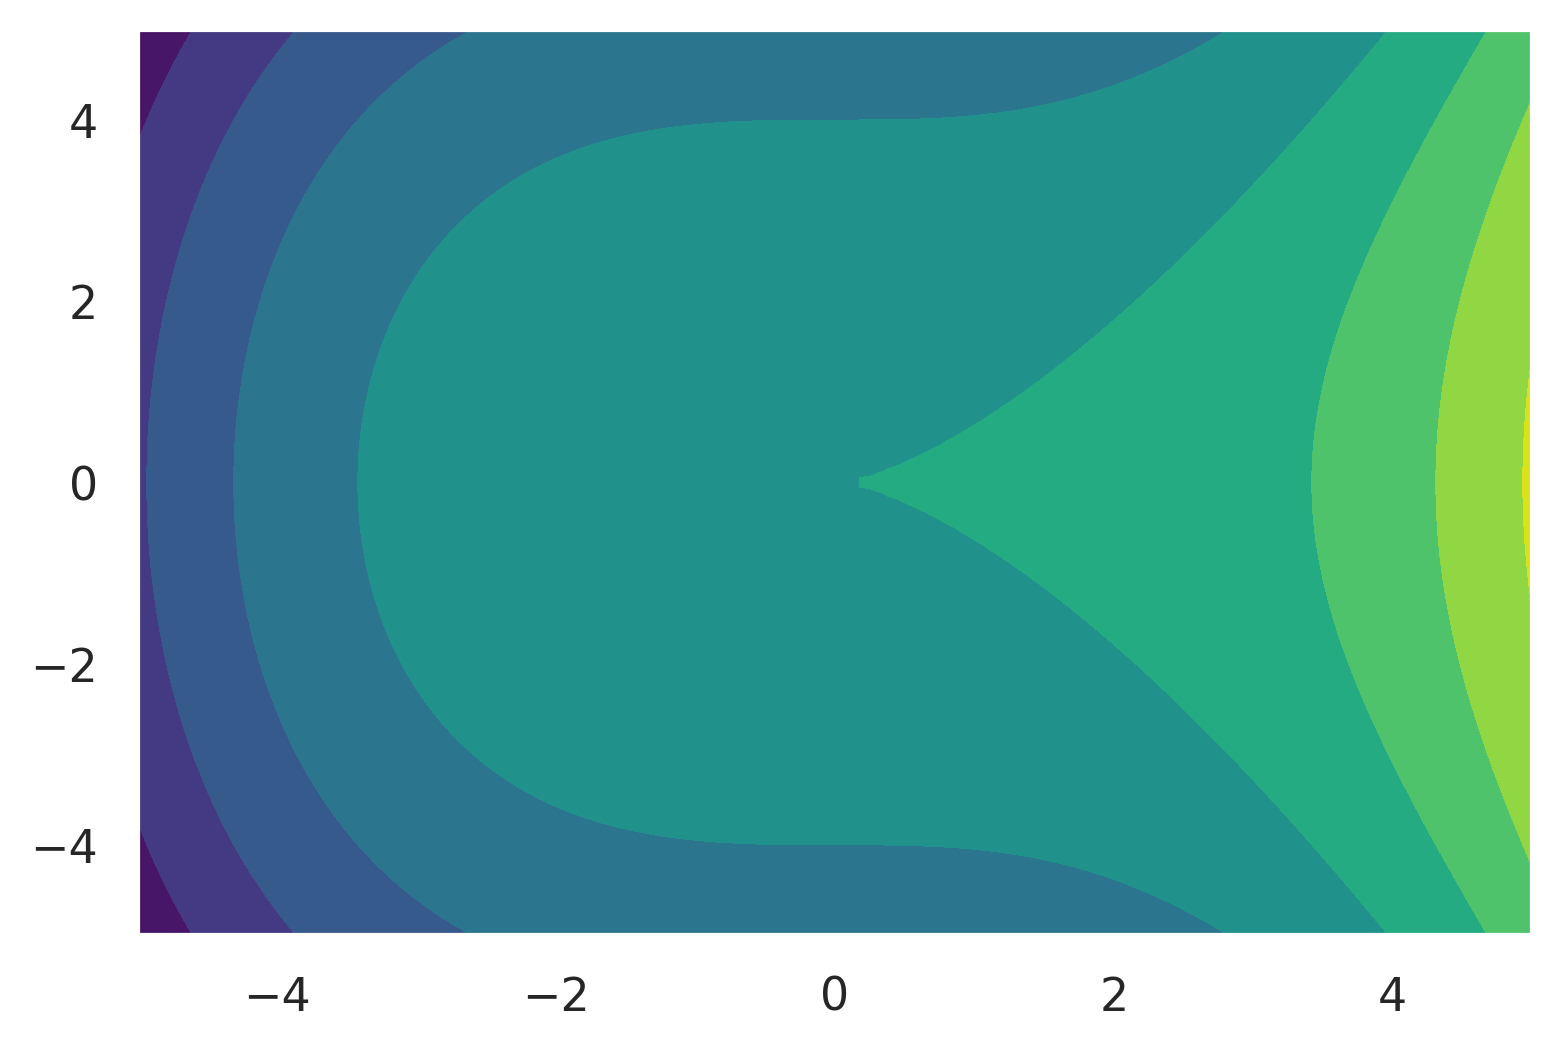

In [61]:
fig, ax = plt.subplots()
grid_x = np.linspace(*dimlims, 100)
grid_y = np.linspace(*dimlims, 100)
xx, yy = np.meshgrid(grid_x, grid_y)
points = np.hstack((xx.ravel().reshape(-1, 1), yy.ravel().reshape(-1, 1)))
ax.contourf(xx, yy, func(points[:, 0], points[:, 1], 0).reshape(xx.shape),
           cmap='viridis')

## Simple grid method

In [62]:
points_per_dim = 3

In [63]:
def get_grid(points_per_dim):
    grid = np.hstack(
        [xx.reshape(-1, 1) for xx in np.meshgrid(*[np.linspace(-5., 5., points_per_dim) for _ in range(ndim)])]
    )
    return grid

In [64]:
grid = get_grid(3)
grid_fvalues = func(grid[:, 0], grid[:, 1], 0)

In [65]:
test_size = 200
test_points = 10. * np.random.random(size=(test_size, ndim)) - 5.
test_fvalues = func(test_points[:, 0], test_points[:, 1], test_points[:, 2])  # evaluate function at test points

Натренируйте ансамблевую модель `ExtraTreesRegressor` на простой сетке точек. Оцените качество на тестовой выборке

In [66]:
model = ExtraTreesRegressor()
model.fit(grid, grid_fvalues)
r2_score(test_fvalues, model.predict(test_points))

0.3413662478437409

## Latin Hypercube Method (LHS)

In [67]:
from pyDOE2 import lhs
lhs_points = 10. * lhs(ndim, samples=points_per_dim ** ndim) - 5.
lhs_fvalues = func(lhs_points[:, 0], lhs_points[:, 1], lhs_points[:, 2])   # evaluate function at lhs points

Натренируйте ту же модель на наборе точек LHS. Оцените качество на тестовой выборке

In [68]:
model = ExtraTreesRegressor()
model.fit(lhs_points, lhs_fvalues)
r2_score(test_fvalues, model.predict(test_points))

0.8896004408381752

## Adaptive sampling

In [69]:
from minlpe import minlpe
adaptive_points, adaptive_fvalues, _ = minlpe(lambda x: func(x[0], x[1], x[2]), [[-5., 5.]] * ndim, maxSampleSize=points_per_dim ** ndim,
                                              folder='adaptive')

Натренируйте модель еще раз на наборе точек полученнных с помощью адаптивного сэмплинга и оцените качество на тестовой выборке

In [70]:
model = ExtraTreesRegressor()
model.fit(adaptive_points, adaptive_fvalues)
r2_score(test_fvalues, model.predict(test_points))

0.9475416324949413

Пример генерации точек адаптивным сэплингом в режиме online.

In [71]:
from minlpe import nextPoint
samplerParams = dict(seed=0, samplerTimeConstraint=None, debug=False)
X = [[-5.0, -5.0, 0.], [5.0, 5.0, 0.]]
Y = [func(*x) for x in X]
newX1 = nextPoint(X, Y, bounds=[[-5, 5], [-5, 5], [-5, 5]], **samplerParams)
newX1  # новые параметры "эксперимента"

array([-4.972615,  5.      ,  0.      ])

In [72]:
X.append(newX1)  
Y.append(func(*newX1))  # новое "экспериментальное" значение для параметров предлложенных алгоритмом
newX2 = nextPoint(X, Y, bounds=[[-5, 5], [-5, 5], [-5, 5]], **samplerParams)
newX2

array([ 5.       , -4.9013264,  0.       ])

In [73]:
for _ in range(50):
    newX = nextPoint(X, Y, bounds=[[-5, 5], [-5, 5], [-5, 5]], **samplerParams)
    newF = func(*newX)
    X.append(newX)  
    Y.append(newF)

<Axes: >

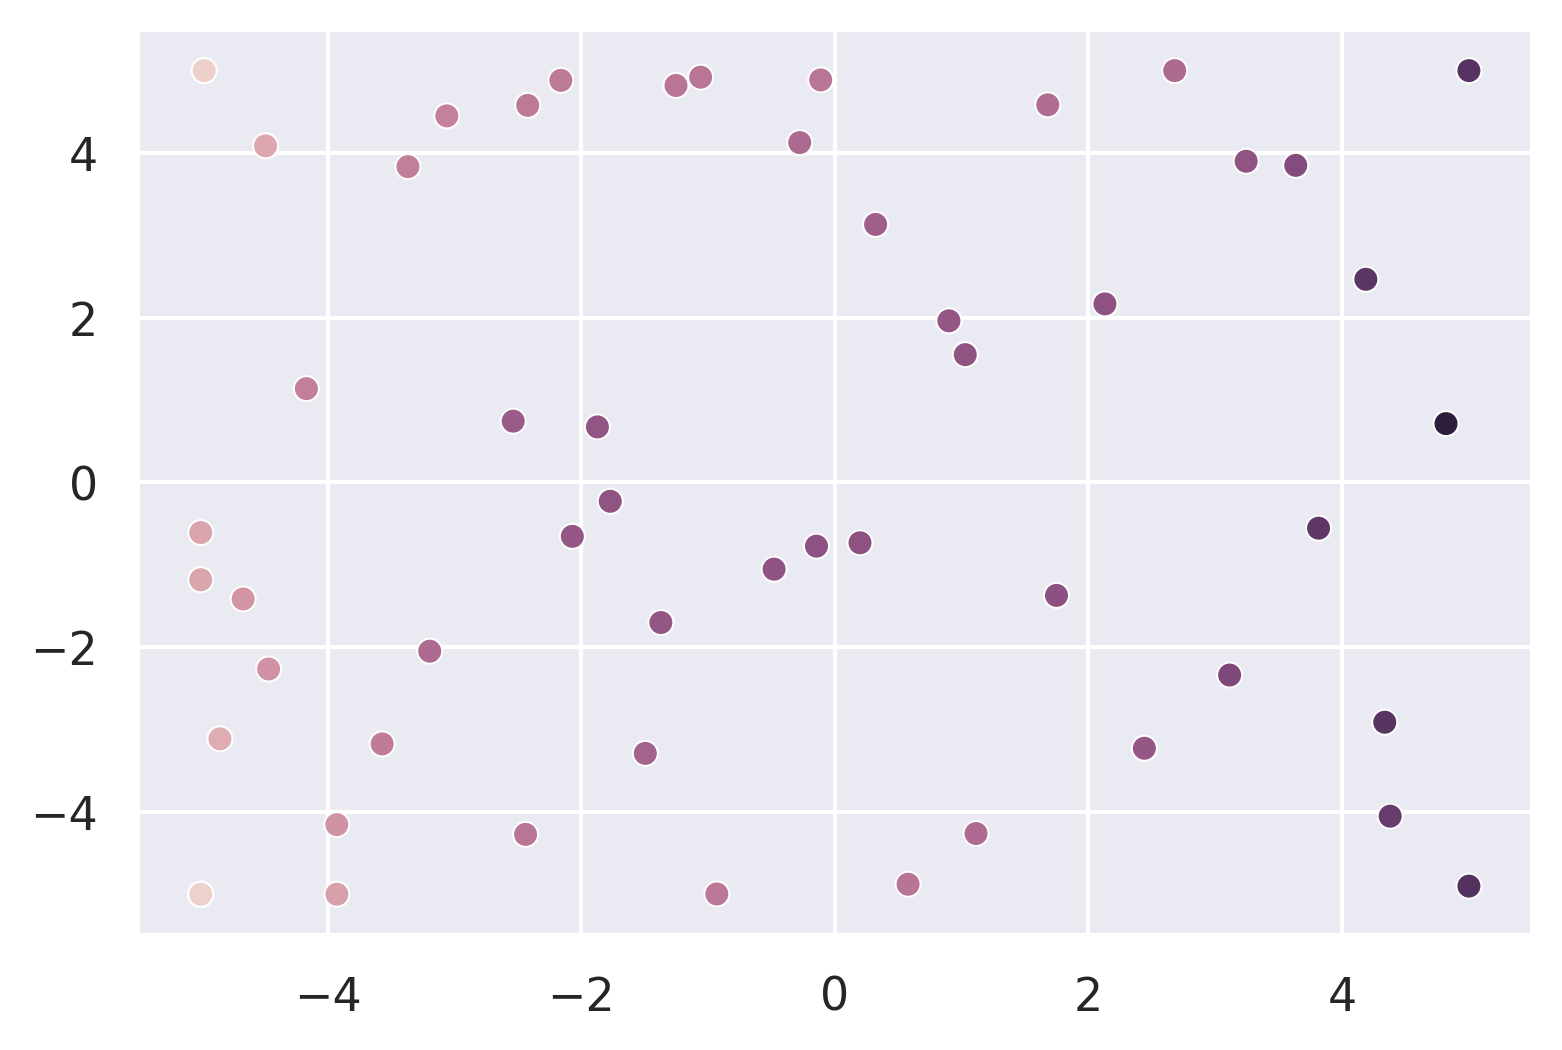

In [74]:
X = np.array(X)
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=Y, legend=False)